# KAMP ModernTCN v4 — 직접 수정하는 노트북

이 파일 안에 전처리, 모델, 학습, 평가 코드가 모두 들어 있습니다. 일반 Python 셀을 수정하고 해당 정의 셀을 다시 실행하면 반영됩니다. 별도의 소스 파일을 만들거나 가져오지 않습니다.

**먼저 파일을 업로드하세요.** 기본값은 `DATA_PATH='/content'`, `ENV_FILE='/content/.env'`입니다.

```text
/content/press_data_normal.csv
/content/outlier_data.csv
/content/.env
```

VS Code의 **Upload to Colab**으로 현재 노트북과 같은 서버에 업로드하세요.
CSV 두 개는 `.env`와 같은 `/content` 폴더에 둡니다. `.env`에는 `WANDB_API_KEY`를 저장합니다 (`USE_WANDB=True`일 때 필요).
위치가 다르면 **3. 실행 옵션**에서 경로를 바꾸세요. PC의 `C:\Users\...` 경로를 입력하지 마세요.

**실행 순서:** Drive 마운트(로컬 저장 시 생략 가능) → 환경 검사·누락 패키지 안전 설치 → import → 실행 설정 → 저장·입력 경로 → 함수/모델 정의 셀 → 데이터 준비 → 선택적 3 epoch 실행 → 본학습 → Test.

- Colab 또는 VS Code의 Colab GPU 커널에서 L4를 우선 선택하고, 할당 불가 시 T4를 선택하세요.
- `STORAGE_MODE`: Drive 백업 또는 Colab 로컬 저장. 로컬은 PC가 아니라 원격 커널의 임시 디스크입니다.
- `DATA_PATH`: 원본 CSV 두 개가 있는 폴더 또는 ZIP. VS Code에서는 Upload to Colab으로 먼저 업로드하세요.
- `USE_WANDB=False`이면 W&B 키와 원격 업로드 없이 진행합니다.
- 소스 압축·해시 확인·별도 사전검사 보고서 생성 단계는 없습니다. 학습에 필요한 Train/Valid 구분과 수치 오류 처리는 유지합니다.
- 학습은 **현재 노트북의 Python 커널**에서 실행됩니다. 계획서와 정확히 같은 Python 환경이 필요하면 Python 3.11 커널을 사용하세요. 기본 Colab Python이 다르면 실행 환경 정보에 기록됩니다.
- 코드/전처리/구조를 수정한 경우 기존 실험을 재개하지 말고 새 실험 ID로 시작하세요.
- 오류가 나면 VS Code의 셀 디버거 또는 새 셀의 `%debug`로 현재 커널의 traceback을 확인할 수 있습니다. `LAST_EXPERIMENT.debug_state`에는 실패한 후보의 설정·history와 학습 중 오류의 모델/optimizer가 남습니다.


In [ ]:
# Drive 백업 사용 시 먼저 실행합니다. 로컬 저장만 사용할 때는 생략할 수 있습니다.
from google.colab import drive
drive.mount('/content/drive')


## 1. 자동 환경 준비 — 기본 패키지 보존 수정본

별도 가상환경(venv)을 생성하지 않고 **현재 Colab Python 커널**을 사용합니다.
Drive 백업을 사용할 때는 위의 마운트 셀을 먼저 실행하세요. 로컬 저장만 사용할 때는 마운트를 생략하고 **3. 실행 옵션**에서 `STORAGE_MODE='local'`로 바꾸세요.

이 셀은 **NumPy / pandas / SciPy / scikit-learn / matplotlib / PyTorch / joblib를 설치하거나 교체하지 않습니다.**
Optuna, W&B, einops, python-dotenv와 그 의존성 중 **없는 것만** 추가합니다. 이미 있으면 현재 버전을 유지합니다.

설치 전 실제 NumPy `random` 연산과 pandas 등 import를 별도 Python 프로세스와 현재 커널에서 검사합니다.
설치가 필요하면 먼저 `pip --dry-run`으로 계획을 확인하고, 기존 패키지가 계획에 포함되면 설치를 차단합니다.
검증된 신규 패키지만 `--no-deps`로 명시하여 설치한 뒤 기존 버전 보존과 import 성공을 다시 확인합니다.
`ENV_MODE='colab'`을 그대로 사용하세요. **고정 버전 강제 설치(`pinned`)와 커널 강제 종료/자동 재시작 코드는 제거했습니다.**

### 이미 `numpy.dtype size changed` 오류가 발생한 환경

이 수정본은 **이미 손상된 NumPy 바이너리를 자동 복구하는 파일이 아닙니다.**
설치 전 별도 프로세스에서도 실패하면 설치를 진행하지 않고 Python/패키지 진단을 출력합니다.
기존 메모리만 불일치하면 세션 다시 시작이 도움이 될 수 있지만, 디스크의 설치 파일이 불일치하면 그것만으로 복구되지 않을 수 있습니다.

**현재 오류 환경을 새로 시작할 때:** `/content`의 CSV, `.env`, 체크포인트·SQLite DB 등 미백업 파일을 먼저 PC/Drive에 보관하세요.
그다음 Colab의 **런타임 → 연결 해제 및 런타임 삭제**로 새 런타임에 연결하고 이 수정본을 실행하세요.
런타임 삭제 시 `/content`의 임시 파일은 사라지므로 필요한 파일을 다시 업로드해야 합니다. 이 노트북은 삭제를 자동 실행하지 않습니다.
VS Code를 쓰는 경우 새 Colab 서버/커널에 연결하세요. 새 환경에서도 import가 실패하면 출력된 버전·경로 진단이 필요합니다.

### 유지되는 실험 설정

전처리, 데이터 분할, 모델, HPO/early stopping, 평가, 저장·재개 설정은 원본과 같습니다.
계획서 고정 환경과 실제 버전은 다를 수 있으며 `KAMP_PACKAGE_VERSIONS`와 기존 실험 config에 실제 버전을 기록합니다.
**실행 옵션의 `RESUME_EXPERIMENT_ID`도 원본의 빈 문자열을 유지합니다.** 기존 실험 재개 시 본인의 기존 ID를 넣으세요.
`KAMP_ENV_DIAGNOSTICS`에서 환경 검사 결과를 확인할 수 있습니다. W&B 로그인/학습은 이 셀에서 실행하지 않습니다.
이 수정은 패키지 설치에 따른 ABI 충돌 예방용이며 Colab 서비스의 세션 시간/사용량 제한을 없애지는 않습니다.

참고: [NumPy ABI 문제](https://numpy.org/doc/stable/user/troubleshooting-importerror.html),
[pip install 옵션](https://pip.pypa.io/en/stable/cli/pip_install/),
[Colab 환경 초기화](https://research.google.com/colaboratory/faq.html)


In [ ]:
# Colab 기본 패키지 보존: 이 셀은 커널을 종료하거나 자동 재시작하지 않습니다.
print("실행 전 업로드 안내\n  /content/press_data_normal.csv\n  /content/outlier_data.csv\n  /content/.env  (USE_WANDB=True일 때)\nVS Code에서는 현재 커널에 Upload to Colab으로 업로드하세요.\n")

import os, sys, json, re, subprocess, tempfile, importlib
from pathlib import Path
from importlib import metadata

ENV_MODE = 'colab'  # 안전 설치 전용. 기존 'pinned' 강제 설치/자동 재시작 모드는 제거했습니다.
_KAMP_ENV_READY = False
_KAMP_RESTART_REQUIRED = False
KAMP_ENV_DIAGNOSTICS = {}

# 기본 scientific stack: 없거나 고장났어도 이 셀에서 설치/교체하지 않습니다.
_KAMP_CORE = {
    'numpy': 'numpy', 'pandas': 'pandas', 'scipy': 'scipy',
    'scikit-learn': 'sklearn', 'matplotlib': 'matplotlib',
    'torch': 'torch', 'joblib': 'joblib',
}
# 이미 있으면 현재 버전 유지. 새로 추가할 때만 원본 노트북의 버전을 사용합니다.
_KAMP_ADDONS = {
    'optuna': ('4.5.0', 'optuna'), 'wandb': ('0.30.0', 'wandb'),
    'einops': ('0.8.1', 'einops'), 'python-dotenv': ('1.1.1', 'dotenv'),
}
_KAMP_MODULES = {**_KAMP_CORE, **{n: m for n, (_, m) in _KAMP_ADDONS.items()}}
_KAMP_RECOVERY = (
    '현재 커널은 자동 종료하지 않았습니다.\n'
    '설치 파일도 불일치한 환경은 세션 재시작만으로 복구되지 않을 수 있습니다.\n'
    '먼저 /content의 CSV, .env, 미백업 결과를 PC/Drive에 보관한 뒤, Colab의 '
    '[런타임 → 연결 해제 및 런타임 삭제]로 새 런타임에 연결하고 이 수정본을 실행하세요.\n'
    '삭제하면 /content의 로컬 파일은 사라집니다. 이 셀 자체는 삭제를 실행하지 않습니다.\n'
    '새 런타임에서도 실패하면 아래 진단의 Python/패키지 버전과 import 경로를 확인하세요.'
)


def _kamp_name(name):
    return re.sub(r'[-_.]+', '-', name).lower()


def _kamp_installed_version(name):
    try:
        return metadata.version(name)
    except metadata.PackageNotFoundError:
        return None


def _kamp_snapshot():
    # 실제 import 경로에서 선택되는 배포판의 버전을 기록합니다.
    names = {_kamp_name(d.metadata['Name']) for d in metadata.distributions()
             if d.metadata.get('Name')}
    return {n: _kamp_installed_version(n) for n in sorted(names)}


# import numpy만으로는 numpy.random의 바이너리 오류를 놓칠 수 있어 실제 연산도 확인합니다.
_KAMP_CORE_PROBE = r'''
import importlib as _il
from importlib import metadata as _md
import numpy as _np
from numpy.random import RandomState as _RandomState
import pandas as _pd
from scipy.linalg import solve as _solve
from sklearn.preprocessing import MinMaxScaler as _Scaler
from matplotlib.figure import Figure as _Figure
import torch as _torch
import joblib as _joblib
_a = _np.array([[1., 2.], [3., 4.]], dtype=_np.float32)
_RandomState(0).normal(size=2)
_np.random.default_rng(0).normal(size=2)
_pd.DataFrame(_a).to_numpy()
_solve(_np.eye(2), _np.ones(2))
_Scaler().fit_transform(_a)
_Figure()
_torch.from_numpy(_a.copy()).numpy()
_kamp_probe_info = {
    n: {'installed': _md.version(n), 'loaded': str(getattr(_il.import_module(m), '__version__', '')),
        'path': str(getattr(_il.import_module(m), '__file__', ''))}
    for n, m in [('numpy', 'numpy'), ('pandas', 'pandas'), ('scipy', 'scipy'),
                 ('scikit-learn', 'sklearn'), ('matplotlib', 'matplotlib'),
                 ('torch', 'torch'), ('joblib', 'joblib')]
}
'''
_KAMP_ADDON_PROBE = r'''
import optuna as _optuna
from optuna.storages import RDBStorage as _RDBStorage
from optuna.trial import TrialState as _TrialState
import wandb as _wandb
from dotenv import dotenv_values as _dotenv_values
from einops import rearrange as _rearrange
from einops.layers.torch import Rearrange as _Rearrange
_rearrange(_a, 'b c -> c b')
# W&B login/init, 실제 Optuna study 생성, 모델 학습은 여기서 실행하지 않습니다.
'''


def _kamp_probe(stage, addons=False, current_kernel=False):
    code = _KAMP_CORE_PROBE + (_KAMP_ADDON_PROBE if addons else '')
    if current_kernel:
        namespace = {}
        try:
            exec(compile(code, '<KAMP environment check>', 'exec'), namespace)
        except Exception as exc:
            KAMP_ENV_DIAGNOSTICS[stage] = f'{type(exc).__name__}: {exc}'
            raise RuntimeError(
                f'[{stage}] 새 Python 프로세스 검사는 통과했지만 현재 커널 import가 실패했습니다.\n'
                '메모리에 이전/부분 로드된 모듈이 남았을 수 있습니다. 설치를 더 하지 말고 '
                '먼저 세션을 한 번 다시 시작해 이 셀을 실행하세요.\n'
                f'원래 오류: {type(exc).__name__}: {exc}'
            ) from exc
        return namespace['_kamp_probe_info']
    # 현재 노트북의 검색 경로를 함께 전달해 다른 Python/경로를 검사하는 오류를 피합니다.
    prefix = 'import sys\nsys.path = ' + repr([p for p in sys.path if isinstance(p, str)]) + '\n'
    suffix = "\nimport json\nprint('__KAMP_PROBE__' + json.dumps(_kamp_probe_info))\n"
    try:
        result = subprocess.run(
            [sys.executable, '-c', prefix + code + suffix],
            text=True, capture_output=True, timeout=180,
            env={**os.environ, 'MPLBACKEND': 'Agg', 'CUBLAS_WORKSPACE_CONFIG': ':4096:8'},
        )
    except subprocess.TimeoutExpired as exc:
        raise RuntimeError(f'[{stage}] import 검사가 제한 시간을 초과했습니다. 설치하지 말고 환경을 확인하세요.') from exc
    if result.returncode:
        detail = (result.stdout + '\n' + result.stderr)[-12000:]
        KAMP_ENV_DIAGNOSTICS[stage] = detail
        print(detail)
        raise RuntimeError(f'[{stage}] 별도 Python 프로세스에서도 import/연산이 실패했습니다.\n' + _KAMP_RECOVERY)
    lines = [line[len('__KAMP_PROBE__'):] for line in result.stdout.splitlines()
             if line.startswith('__KAMP_PROBE__')]
    if not lines:
        raise RuntimeError(f'[{stage}] 검사 결과를 읽지 못했습니다. 패키지를 임의로 재설치하지 마세요.')
    info = json.loads(lines[-1])
    KAMP_ENV_DIAGNOSTICS[stage] = info
    return info


def _kamp_dependency_issues():
    # 직접/간접 의존성 및 extras/환경 마커를 확인합니다. --no-deps만 사용했을 때의 누락도 탐지합니다.
    from packaging.requirements import Requirement
    missing, conflicts, seen = set(), set(), set()
    pending = [(name, frozenset()) for name in _KAMP_ADDONS]
    while pending:
        name, extras = pending.pop()
        name = _kamp_name(name)
        if (name, extras) in seen:
            continue
        seen.add((name, extras))
        try:
            dist = metadata.distribution(name)
        except metadata.PackageNotFoundError:
            missing.add(name)
            continue
        for text in dist.requires or []:
            req = Requirement(text)
            if req.marker and not any(req.marker.evaluate({'extra': extra}) for extra in ('', *extras)):
                continue
            installed = _kamp_installed_version(req.name)
            if installed is None:
                missing.add(_kamp_name(req.name))
            elif req.specifier and not req.specifier.contains(installed, prereleases=True):
                conflicts.add(f'{name}: {req} 필요 / 현재 {req.name}=={installed}')
            pending.append((req.name, frozenset(req.extras)))
    return sorted(missing), sorted(conflicts)


def _kamp_pip(args, stage):
    # 외부 PIP_* 설정의 강제 재설치/별도 설치 경로 옵션이 끼어들지 않게 합니다.
    env = {k: v for k, v in os.environ.items() if not k.startswith('PIP_')}
    env['PIP_CONFIG_FILE'] = os.devnull
    result = subprocess.run(
        [sys.executable, '-m', 'pip', '--disable-pip-version-check', '--no-input', *args],
        text=True, capture_output=True, env=env, timeout=600,
    )
    KAMP_ENV_DIAGNOSTICS[stage] = (result.stdout + '\n' + result.stderr)[-16000:]
    if result.returncode:
        print(KAMP_ENV_DIAGNOSTICS[stage])
        raise RuntimeError(
            f'[{stage}] 실패했습니다. 제한을 풀어 NumPy 등을 재설치하지 않습니다.\n'
            '위 로그에서 네트워크 오류, 지정 버전/wheel 미제공, 기존 의존성 충돌을 확인하세요.'
        )


def _kamp_install_addons(before):
    roots = [f'{n}=={before.get(_kamp_name(n)) or target}'
             for n, (target, _) in _KAMP_ADDONS.items()]
    with tempfile.TemporaryDirectory(prefix='kamp_safe_deps_') as tmp:
        constraints = Path(tmp) / 'keep-installed.txt'
        report = Path(tmp) / 'plan.json'
        constraints.write_text('\n'.join(f'{n}=={v}' for n, v in before.items() if v), encoding='utf-8')
        # 계획만 생성: 이 단계에서는 패키지를 설치하지 않습니다.
        _kamp_pip(['install', '--dry-run', '--report', str(report),
                   '--only-binary=:all:', '--constraint', str(constraints),
                   '--index-url', 'https://pypi.org/simple', *roots], '설치 계획 확인')
        plan = json.loads(report.read_text(encoding='utf-8')).get('install', [])
        planned = [(_kamp_name(item['metadata']['name']), item['metadata']['version']) for item in plan]
        forbidden = [f'{n}=={v}' for n, v in planned if n in before or n in _KAMP_CORE]
        if forbidden:
            raise RuntimeError('기존/보호 패키지 설치를 차단했습니다. 실제 설치 없음: ' + ', '.join(forbidden))
        if _kamp_snapshot() != before:
            raise RuntimeError('설치 계획 확인 중 환경이 변경되었습니다. 다른 셀의 pip 실행을 멈추고 다시 확인하세요.')
        if planned:
            print('없는 패키지/의존성만 추가:', ', '.join(f'{n}=={v}' for n, v in planned), flush=True)
            # 검증한 신규 패키지만 명시적으로 설치. 실제 설치 단계에서는 의존성 재해석 금지.
            _kamp_pip(['install', '--no-deps', '--only-binary=:all:',
                       '--constraint', str(constraints), '--index-url', 'https://pypi.org/simple',
                       *[f'{n}=={v}' for n, v in planned]], '신규 패키지 설치')
            importlib.invalidate_caches()
        KAMP_ENV_DIAGNOSTICS['added_packages'] = dict(planned)


def _kamp_prepare_environment():
    global _KAMP_ENV_READY, KAMP_PACKAGE_VERSIONS
    _KAMP_ENV_READY = False
    if ENV_MODE != 'colab':
        raise ValueError("이 수정본은 ENV_MODE='colab'만 지원합니다. pinned 설치는 제거했습니다.")
    if _kamp_installed_version('packaging') is None:
        raise RuntimeError('Colab 기본 packaging 패키지를 찾을 수 없습니다.\n' + _KAMP_RECOVERY)
    from packaging.version import Version
    before = _kamp_snapshot()
    KAMP_ENV_DIAGNOSTICS['python'] = sys.version
    KAMP_ENV_DIAGNOSTICS['before'] = {n: before.get(n) for n in _KAMP_MODULES}
    missing_core = [n for n in _KAMP_CORE if not before.get(n)]
    if missing_core:
        raise RuntimeError('Colab 기본 패키지 누락: ' + ', '.join(missing_core) + '\n' + _KAMP_RECOVERY)
    print('기존 기본 패키지:', {n: before[n] for n in _KAMP_CORE})
    print('기존 NumPy/Pandas 바이너리 호환성을 먼저 검사합니다.', flush=True)
    _kamp_probe('설치 전 별도 프로세스')
    stale = []
    for name, module in _KAMP_MODULES.items():
        loaded = getattr(sys.modules.get(module), '__version__', None)
        installed = before.get(name)
        if loaded is not None and (installed is None or Version(str(loaded)) != Version(installed)):
            stale.append(f'{name}: 메모리={loaded}, 설치={installed}')
    if stale:
        raise RuntimeError('디스크 검사 성공, 메모리 버전 불일치: ' + '; '.join(stale) +
                           '\n설치는 실행하지 않았습니다. 세션을 한 번 다시 시작한 뒤 이 셀을 실행하세요.')
    # 설치 전에 현재 커널에서도 검사. 실패한 모듈을 reload하여 숨기지 않습니다.
    os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
    _kamp_probe('설치 전 현재 커널', current_kernel=True)
    missing, conflicts = _kamp_dependency_issues()
    if conflicts:
        raise RuntimeError('이미 설치된 의존성 버전이 맞지 않습니다. 자동 변경하지 않습니다.\n' + '\n'.join(conflicts))
    if missing:
        print('추가 확인 대상:', ', '.join(missing), flush=True)
        _kamp_install_addons(before)
    else:
        print('추가 패키지와 의존성이 이미 있습니다. pip 설치를 생략합니다.')
        KAMP_ENV_DIAGNOSTICS['added_packages'] = {}
    after = _kamp_snapshot()
    changed = [f'{n}: {v} → {after.get(n)}' for n, v in before.items() if after.get(n) != v]
    if changed:
        raise RuntimeError('설치 전후 기존 패키지 버전 변경을 감지했습니다. 학습을 시작하지 않습니다.\n' + '\n'.join(changed))
    missing, conflicts = _kamp_dependency_issues()
    if missing or conflicts:
        raise RuntimeError(f'추가 패키지 의존성 검사 실패: 누락={missing}, 충돌={conflicts}')
    _kamp_probe('설치 후 별도 프로세스', addons=True)
    _kamp_probe('설치 후 현재 커널', addons=True, current_kernel=True)
    KAMP_PACKAGE_VERSIONS = {n: _kamp_installed_version(n) for n in _KAMP_MODULES}
    _KAMP_ENV_READY = True
    print('환경 준비 완료: 기존 패키지 보존, NumPy/Pandas/추가 패키지 import 검사 통과.')
    print('이 셀은 커널 종료/자동 재시작을 실행하지 않습니다. 다음 셀로 진행하세요.')
    print('실제 패키지 버전:', KAMP_PACKAGE_VERSIONS)
    print('현재 Python:', sys.version)


_kamp_prepare_environment()


## 2. 라이브러리


In [2]:
# 설치 셀이 성공한 현재 커널에서만 라이브러리를 불러옵니다.
if not globals().get('_KAMP_ENV_READY', False):
    raise RuntimeError('먼저 1번 자동 환경 준비 셀을 실행하세요. True/False 변경은 필요 없습니다.')

import os
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
from pathlib import Path
from types import SimpleNamespace
from fractions import Fraction
from contextlib import contextmanager
from datetime import datetime, timezone
import copy, io, json, math, pickle, random, shutil, sqlite3
import subprocess, sys, tarfile, time, traceback, uuid, zipfile, warnings

import numpy as np
import pandas as pd
import joblib
import torch
from torch import nn
import torch.nn.functional as F
from torch.nn.utils import weight_norm
from torch.utils.data import DataLoader, TensorDataset
from einops import rearrange, repeat, reduce
from einops.layers.torch import Rearrange
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_auc_score, confusion_matrix
import optuna
from optuna.trial import TrialState
from IPython.display import display, Image, FileLink

FEATURES = ['AI0_Vibration', 'AI1_Vibration', 'AI2_Current']
CSV_NAMES = ('press_data_normal.csv', 'outlier_data.csv')
POLICIES = ('guide_pr_equal', 'valid_max_f1')
CHECKPOINTS = ('best_normal_val_loss', 'best_valid_ap', 'last')


## 3. 실행 옵션

### W&B 키를 .env에서 불러오기
`.env` 파일에 `WANDB_API_KEY=본인_API_키`를 저장합니다. 이 내용을 코드 셀에 붙여넣지 마세요.
VS Code + Colab에서는 `.env` 파일을 **Upload to Colab**으로 업로드한 다음
`USE_WANDB=True`, `ENV_FILE='/content/.env'`로 설정합니다.
PC의 `.env` 파일은 원격 Colab 커널에서 자동으로 읽을 수 없습니다.
`ENV_FILE=''`이면 커널 작업 폴더의 `.env`, `/content/.env` 순서로 찾습니다.
인증 우선순위는 **.env → 기존 환경변수**입니다. 수동 키 입력창은 사용하지 않습니다.
명시한 파일이 없거나 파일에 키가 비어 있으면 경로/값을 고치도록 안내합니다.
`USE_WANDB=False`일 때는 파일 읽기와 인증을 건너뜁니다.
키는 실험 설정이나 결과 파일에 저장하지 않습니다. `.env`는 결과 폴더 밖에 두세요.


In [3]:
# 여기에서 실행 옵션을 바꿉니다. 경로는 실행 중인 커널 기준입니다.
MODEL = 'moderntcn'
STORAGE_MODE = 'drive'   # 'drive': Drive에도 백업 / 'local': 커널의 로컬 디스크
DATA_PATH = '/content'  # .env와 같은 폴더에 원본 CSV 두 개를 업로드
# 다른 위치를 사용할 때만 수정합니다. ZIP 파일 경로도 지정할 수 있습니다.
# VS Code + Colab: 탐색기의 Upload to Colab으로 업로드한 뒤 위에 서버 경로 입력
RESUME_EXPERIMENT_ID = ''
RUN_SMOKE = True        # 본학습 전 3 epoch를 별도 가중치로 실행
USE_WANDB = True        # False이면 W&B 인증·원격 업로드 없이 저장 위치에만 저장
ENV_FILE = '/content/.env'     # WANDB_API_KEY가 들어 있는 업로드된 .env 파일
ENTITY = 'Yellow_Mongoose'
PROJECT = 'kamp-predictive-maintenance'
GROUP = 'kamp_lstm_moderntcn_v4_validloss_all'
MAX_EPOCHS = 800
N_TRIALS = 8
SEED = 42
BATCH_SIZE = 128
PLOT_EVERY = 10         # 학습 곡선을 갱신할 epoch 간격 (상태 표는 매 epoch 갱신)

# 연결된 GPU에서 L4 우선, 없으면 T4를 사용합니다.
# Colab 서버의 GPU 종류 변경/신규 할당은 Colab 또는 VS Code 커널 메뉴에서 합니다.
if not torch.cuda.is_available():
    raise RuntimeError('L4 또는 T4 GPU 커널을 연결한 뒤 실행하세요.')
gpu_list = [(i, torch.cuda.get_device_name(i)) for i in range(torch.cuda.device_count())]
GPU_INDEX = next((i for preferred in ('L4', 'T4') for i, name in gpu_list
                  if preferred in name.upper().split()), None)
if GPU_INDEX is None:
    raise RuntimeError(f'L4/T4가 없습니다. 현재 장치: {gpu_list}')
torch.cuda.set_device(GPU_INDEX)
DEVICE = f'cuda:{GPU_INDEX}'
GPU_NAME = torch.cuda.get_device_name(GPU_INDEX)
print('사용 GPU:', GPU_NAME)


사용 GPU: NVIDIA L4


## 4. 저장·인증·데이터 경로


In [ ]:
if STORAGE_MODE not in ('drive', 'local'):
    raise ValueError('STORAGE_MODE는 drive 또는 local입니다.')
if STORAGE_MODE == 'drive':
    from google.colab import drive
    if not Path('/content/drive/MyDrive').exists():
        drive.mount('/content/drive')
    RESULT_BASE = Path('/content/drive/MyDrive/KAMP_comparison_v4_validloss_all')
else:
    RESULT_BASE = Path('/content/KAMP_results_v4_validloss_all')

def load_wandb_env(env_file=''):
    # 명시 경로가 없으면 현재 커널 작업 폴더와 /content의 .env만 찾습니다.
    candidates = ([Path(env_file).expanduser()] if env_file else
                  [Path.cwd() / '.env', Path('/content/.env')])
    env_path = next((p for p in candidates if p.is_file()), None)
    if env_path is None:
        if env_file:
            raise FileNotFoundError(
                'ENV_FILE을 찾을 수 없습니다. .env를 Colab 서버에 업로드하고 '
                'ENV_FILE에 서버 경로(예: /content/.env)를 입력하세요.'
            )
        return False
    try:
        from dotenv import dotenv_values
    except ImportError as exc:
        # 설치는 1번 환경 준비 셀에서만 수행합니다. 인증 중 별도 pip 실행 없음.
        raise RuntimeError(
            'python-dotenv import가 실패했습니다. 1번 자동 환경 준비 셀의 진단을 확인하세요. '
            '이 인증 함수에서는 패키지를 설치하거나 커널을 재시작하지 않습니다.'
        ) from exc
    key = dotenv_values(env_path, encoding='utf-8-sig', interpolate=False).get('WANDB_API_KEY')
    if not key or not key.strip():
        raise ValueError('.env에 WANDB_API_KEY 값이 없습니다. 값을 입력한 뒤 다시 실행하세요.')
    # 파일 값을 우선 사용합니다. 키/파일 내용은 출력하거나 실험 config에 넣지 않습니다.
    os.environ['WANDB_API_KEY'] = key.strip()
    return True

if USE_WANDB:
    if load_wandb_env(ENV_FILE):
        print('W&B 인증 키를 .env에서 불러왔습니다. (키 값은 출력하지 않음)')

if USE_WANDB and not os.environ.get('WANDB_API_KEY', '').strip():
    raise ValueError(
        'W&B 키가 로드되지 않았습니다. /content/.env에 WANDB_API_KEY를 저장하고 '
        'ENV_FILE 경로를 확인한 뒤 이 셀을 다시 실행하세요. 수동 키 입력은 사용하지 않습니다.'
    )

if RESUME_EXPERIMENT_ID:
    EXPERIMENT_ID = RESUME_EXPERIMENT_ID
elif globals().get('_CURRENT_MODEL') != MODEL or not globals().get('EXPERIMENT_ID'):
    EXPERIMENT_ID = MODEL + '_validloss_all_' + datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%SZ') + '_' + uuid.uuid4().hex[:8]
_CURRENT_MODEL = MODEL
OUTPUT_DIR = RESULT_BASE / MODEL / EXPERIMENT_ID
LOCAL_DIR = Path('/content/KAMP_v4_runs') / EXPERIMENT_ID
LOCAL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if not RESUME_EXPERIMENT_ID and not DATA_PATH:
    DATA_PATH = '/content'

config = dict(model=MODEL, experiment_id=EXPERIMENT_ID,
    protocol=MODEL+'_hpo_v4_validloss_all', local_dir=str(LOCAL_DIR),
    drive_dir=str(OUTPUT_DIR), data_path=DATA_PATH, max_epochs=MAX_EPOCHS,
    n_trials=N_TRIALS, device=DEVICE, wandb=USE_WANDB,
    entity=ENTITY, project=PROJECT, group=GROUP, seed=SEED, batch_size=BATCH_SIZE,
    plot_every=PLOT_EVERY, notebook_format='inline_v1',
    environment_mode=ENV_MODE, package_versions=KAMP_PACKAGE_VERSIONS)
print('실험 ID:', EXPERIMENT_ID)
print('결과 위치:', OUTPUT_DIR)
print('Python:', sys.version.split()[0], '| PyTorch:', torch.__version__)
if sys.version_info[:2] != (3, 11):
    print('참고: 이 노트북은 현재 커널을 사용합니다. 계획서의 Python 3.11 환경과는 다릅니다.')


## 5. 데이터 준비 함수
정상 Raw 7:1:2, 이상 Raw 0:200:400으로 먼저 분할합니다. abs + 정상 Train 기준 MinMax, W20, label offset 120입니다.


In [9]:
def json_clean(x):
    if isinstance(x, dict):
        return {str(k): json_clean(v) for (k, v) in x.items()}
    if isinstance(x, (list, tuple)):
        return [json_clean(v) for v in x]
    if isinstance(x, np.ndarray):
        return json_clean(x.tolist())
    if isinstance(x, np.generic):
        return json_clean(x.item())
    if isinstance(x, float) and (not np.isfinite(x)):
        return None
    if isinstance(x, Path):
        return str(x)
    return x

def write_json(path, obj):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_name(path.name + '.tmp')
    tmp.write_text(json.dumps(json_clean(obj), ensure_ascii=False, indent=2, allow_nan=False), encoding='utf-8')
    os.replace(tmp, path)

def collect_csv(zip_path):
    found = {}

    def visit(content, depth=0):
        if depth > 4:
            raise ValueError('ZIP nesting too deep')
        with zipfile.ZipFile(io.BytesIO(content)) as z:
            for info in z.infolist():
                name = Path(info.filename).name
                if name in CSV_NAMES:
                    data = z.read(info)
                    if name in found and found[name] != data:
                        raise ValueError('Ambiguous CSV ' + name)
                    found[name] = data
                elif info.filename.lower().endswith('.zip'):
                    visit(z.read(info), depth + 1)
    visit(Path(zip_path).read_bytes())
    if set(found) != set(CSV_NAMES):
        raise ValueError('ZIP must contain both expected CSVs')
    return found

def load_csv_sources(data_path):
    path = Path(data_path)
    if path.is_dir():
        return {name: (path / name).read_bytes() for name in CSV_NAMES}
    return collect_csv(path)

def prepare_data(data_path, out):
    out = Path(out)
    out.mkdir(parents=True, exist_ok=True)
    sources = load_csv_sources(data_path)
    frames = {}
    audit = {}
    gap_rows = []
    keys = ['TimeStamp'] + FEATURES + ['Equipment_state']
    for (name, blob) in sources.items():
        df = pd.read_csv(io.BytesIO(blob))
        df['raw_row'] = np.arange(len(df))
        if df[keys].isna().any().any():
            raise ValueError('NaN in ' + name)
        if not np.isfinite(df[FEATURES].to_numpy(dtype=np.float64)).all():
            raise ValueError('Nonfinite sensors')
        expected_label = 0 if name == 'press_data_normal.csv' else 1
        assert len(df) == (20000 if expected_label == 0 else 600)
        assert (df.Equipment_state == expected_label).all()
        dup = df.duplicated(keys, keep='first')
        dropped = df.loc[dup, 'raw_row'].tolist()
        assert len(dropped) == (1 if expected_label == 0 else 0)
        df = df.loc[~dup].copy()
        df['TimeStamp'] = pd.to_datetime(df.TimeStamp, errors='raise')
        if df.TimeStamp.duplicated().any():
            raise ValueError('Timestamp collision after exact dedup')
        df = df.sort_values('TimeStamp', kind='stable').reset_index(drop=True)
        dt = df.TimeStamp.diff().dt.total_seconds()
        nominal = float(dt.dropna().mode().iloc[0])
        gap = dt > nominal * 1.5
        for i in np.flatnonzero(gap):
            gap_rows.append({'source_file': name, 'previous_raw_row': int(df.raw_row.iloc[i - 1]), 'next_raw_row': int(df.raw_row.iloc[i]), 'seconds': float(dt.iloc[i])})
        audit[name] = {'original_rows': len(df) + len(dropped), 'deduplicated_rows': len(df), 'dropped_raw_rows': dropped, 'nominal_seconds': nominal, 'gap_definition': 'delta > 1.5 * modal delta (audit only)', 'gap_count': int(gap.sum()), 'start': str(df.TimeStamp.iloc[0]), 'end': str(df.TimeStamp.iloc[-1])}
        frames[name] = df
    normal = frames['press_data_normal.csv']
    abnormal = frames['outlier_data.csv']
    (n1, n2) = (int(np.floor(0.7 * len(normal))), int(np.floor(0.8 * len(normal))))
    splits = {'train': [('press_data_normal.csv', normal.iloc[:n1])], 'valid': [('press_data_normal.csv', normal.iloc[n1:n2]), ('outlier_data.csv', abnormal.iloc[:200])], 'test': [('press_data_normal.csv', normal.iloc[n2:]), ('outlier_data.csv', abnormal.iloc[200:])]}
    scaler = MinMaxScaler().fit(np.abs(normal.iloc[:n1][FEATURES].to_numpy(dtype=np.float64)))
    joblib.dump(scaler, out / 'scaler.joblib')
    manifests = []
    summaries = []
    used = {}
    raw_sets = {}
    for (split, parts) in splits.items():
        xs = []
        ys = []
        used[split] = set()
        raw_sets[split] = set()
        rows = []
        for (name, df) in parts:
            a = scaler.transform(np.abs(df[FEATURES].to_numpy(dtype=np.float64))).astype(np.float32)
            ids = df.raw_row.to_numpy()
            times = df.TimeStamp.astype(str).to_numpy()
            labels = df.Equipment_state.to_numpy(dtype=np.int64)
            raw_sets[split].update(((name, int(i)) for i in ids))
            count = len(df) - 120
            x = np.stack([a[i:i + 20] for i in range(count)])
            y = labels[120:]
            xs.append(x)
            ys.append(y)
            summaries.append({'split': split, 'source_file': name, 'label': int(labels[0]), 'raw_rows': len(df), 'windows': count})
            for i in range(count):
                input_ids = ids[i:i + 20]
                used[split].update(((name, int(j)) for j in input_ids))
                used[split].add((name, int(ids[i + 120])))
                rows.append({'source_file': name, 'split': split, 'input_start_row': int(ids[i]), 'input_end_row': int(ids[i + 19]), 'label_row': int(ids[i + 120]), 'input_end_time': times[i + 19], 'label_time': times[i + 120], 'label': int(y[i]), 'input_row_ids': json.dumps(input_ids.tolist())})
        x = np.concatenate(xs)
        y = np.concatenate(ys)
        expected = {'train': (13879, 0), 'valid': (1960, 80), 'test': (4160, 280)}[split]
        assert x.shape == (expected[0], 20, 3) and int(y.sum()) == expected[1]
        np.savez_compressed(out / f'{split}.npz', x=x, y=y)
        pd.DataFrame(rows).to_csv(out / f'{split}_manifest.csv', index=False)
        manifests.extend(rows)
    for (a, b) in [('train', 'valid'), ('train', 'test'), ('valid', 'test')]:
        assert not used[a] & used[b] and (not raw_sets[a] & raw_sets[b])
    pd.DataFrame(manifests).to_csv(out / 'window_manifest.csv', index=False)
    pd.DataFrame(summaries).to_csv(out / 'split_summary.csv', index=False)
    pd.DataFrame(gap_rows, columns=['source_file', 'previous_raw_row', 'next_raw_row', 'seconds']).to_csv(out / 'time_gaps.csv', index=False)
    write_json(out / 'data_audit.json', {'sources': audit, 'shared_input_or_label_rows': 0, 'shared_raw_rows': 0, 'features': FEATURES, 'window': 20, 'label_offset': 120, 'abs': True, 'clip': False, 'gap_policy': 'concatenate inside each source and split', 'scaler_fit': 'normal_train_raw_only'})
    return pd.DataFrame(summaries)

def read_split(out, split):
    with np.load(Path(out) / f'{split}.npz') as z:
        return (z['x'], z['y'])


## 6. 임계값과 평가지표
A: 정확한 Precision=Recall 교점과 score > threshold. B: Valid 최대 F1과 score ≥ threshold. A가 없으면 unavailable로 남깁니다.


In [10]:
def thresholds(y, scores):
    y = np.asarray(y, dtype=np.int64)
    scores = np.asarray(scores, dtype=np.float64)
    if not np.isfinite(scores).all() or set(np.unique(y)) != {0, 1}:
        raise ValueError('Invalid evaluation inputs')
    (p, r, t) = precision_recall_curve(y, scores, drop_intermediate=False)
    equal = np.flatnonzero(p[:-1] == r[:-1])
    order = np.argsort(scores, kind='stable')
    ss = scores[order]
    yy = y[order]
    prefix = np.r_[0, np.cumsum(yy)]
    idx = np.searchsorted(ss, t, side='left')
    tp = int(y.sum()) - prefix[idx]
    pred = len(y) - idx
    ratios = [Fraction(2 * int(a), int(b) + int(y.sum())) for (a, b) in zip(tp, pred)]
    best = max(ratios)
    j = max((i for (i, v) in enumerate(ratios) if v == best))
    return {'guide_pr_equal': float(t[equal[0]]) if len(equal) else None, 'valid_max_f1': float(t[j])}

def metrics(y, scores, threshold, policy):
    ans = {'ap': float(average_precision_score(y, scores)), 'roc_auc': float(roc_auc_score(y, scores)), 'threshold': threshold, 'available': threshold is not None}
    keys = ['accuracy', 'precision', 'recall', 'f1', 'tp', 'tn', 'fp', 'fn', 'fpr', 'fnr']
    if threshold is None:
        return dict(ans, **dict.fromkeys(keys, None))
    pred = scores > threshold if policy == 'guide_pr_equal' else scores >= threshold
    (tn, fp, fn, tp) = map(int, confusion_matrix(y, pred, labels=[0, 1]).ravel())
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    return dict(ans, accuracy=(tp + tn) / len(y), precision=precision, recall=recall, f1=2 * tp / (2 * tp + fp + fn) if 2 * tp + fp + fn else 0.0, tp=tp, tn=tn, fp=fp, fn=fn, fpr=fp / (fp + tn) if fp + tn else 0.0, fnr=fn / (fn + tp) if fn + tp else 0.0)


## ModernTCN: RevIN과 출력 레이어
공식 detection 구현의 구조를 유지하고 import 대신 이 노트북의 클래스를 참조합니다.


In [11]:
class ModernRevIN(nn.Module):
    def __init__(self, num_features: int, eps=1e-5, affine=True, subtract_last=False):
        """
        :param num_features: the number of features or channels
        :param eps: a value added for numerical stability
        :param affine: if True, ModernRevIN has learnable affine parameters
        """
        super(ModernRevIN, self).__init__()
        self.num_features = num_features
        self.eps = eps
        self.affine = affine
        self.subtract_last = subtract_last
        if self.affine:
            self._init_params()

    def forward(self, x, mode:str):
        if mode == 'norm':
            self._get_statistics(x)
            x = self._normalize(x)
        elif mode == 'denorm':
            x = self._denormalize(x)
        else: raise NotImplementedError
        return x

    def _init_params(self):
        # initialize ModernRevIN params: (C,)
        self.affine_weight = nn.Parameter(torch.ones(self.num_features))
        self.affine_bias = nn.Parameter(torch.zeros(self.num_features))

    def _get_statistics(self, x):
        dim2reduce = tuple(range(1, x.ndim-1))
        if self.subtract_last:
            self.last = x[:,-1,:].unsqueeze(1)
        else:
            self.mean = torch.mean(x, dim=dim2reduce, keepdim=True).detach()
        self.stdev = torch.sqrt(torch.var(x, dim=dim2reduce, keepdim=True, unbiased=False) + self.eps).detach()

    def _normalize(self, x):
        if self.subtract_last:
            x = x - self.last
        else:
            x = x - self.mean
        x = x / self.stdev
        if self.affine:
            x = x * self.affine_weight
            x = x + self.affine_bias
        return x

    def _denormalize(self, x):
        if self.affine:
            x = x - self.affine_bias
            x = x / (self.affine_weight + self.eps*self.eps)
        x = x * self.stdev
        if self.subtract_last:
            x = x + self.last
        else:
            x = x + self.mean
        return x

#__all__ = ['Transpose', 'get_activation_fn', 'moving_avg', 'series_decomp', 'PositionalEncoding', 'SinCosPosEncoding', 'Coord2dPosEncoding', 'Coord1dPosEncoding', 'positional_encoding']
__all__ = ['moving_avg', 'series_decomp',  'Flatten_Head']
# decomposition

class moving_avg(nn.Module):
    """
    Moving average block to highlight the trend of time series
    """
    def __init__(self, kernel_size, stride):
        super(moving_avg, self).__init__()
        self.kernel_size = kernel_size
        self.avg = nn.AvgPool1d(kernel_size=kernel_size, stride=stride, padding=0)

    def forward(self, x):
        # padding on the both ends of time series
        front = x[:, 0:1, :].repeat(1, (self.kernel_size - 1) // 2, 1)
        end = x[:, -1:, :].repeat(1, (self.kernel_size - 1) // 2, 1)
        x = torch.cat([front, x, end], dim=1)
        x = self.avg(x.permute(0, 2, 1))
        x = x.permute(0, 2, 1)
        return x


class series_decomp(nn.Module):
    """
    Series decomposition block
    """
    def __init__(self, kernel_size):
        super(series_decomp, self).__init__()
        self.moving_avg = moving_avg(kernel_size, stride=1)

    def forward(self, x):
        moving_mean = self.moving_avg(x)
        res = x - moving_mean
        return res, moving_mean


# forecast task head
class Flatten_Head(nn.Module):
    def __init__(self, individual, n_vars, nf, target_window, head_dropout=0):
        super(Flatten_Head, self).__init__()

        self.individual = individual
        self.n_vars = n_vars

        if self.individual:
            self.linears = nn.ModuleList()
            self.dropouts = nn.ModuleList()
            self.flattens = nn.ModuleList()
            for i in range(self.n_vars):
                self.flattens.append(nn.Flatten(start_dim=-2))
                self.linears.append(nn.Linear(nf, target_window))
                self.dropouts.append(nn.Dropout(head_dropout))
        else:
            self.flatten = nn.Flatten(start_dim=-2)
            self.linear = nn.Linear(nf, target_window)
            self.dropout = nn.Dropout(head_dropout)

    def forward(self, x):  # x: [bs x nvars x d_model x patch_num]
        if self.individual:
            x_out = []
            for i in range(self.n_vars):
                z = self.flattens[i](x[:, i, :, :])  # z: [bs x d_model * patch_num]
                z = self.linears[i](z)  # z: [bs x target_window]
                z = self.dropouts[i](z)
                x_out.append(z)
            x = torch.stack(x_out, dim=1)  # x: [bs x nvars x target_window]
        else:
            x = self.flatten(x)
            x = self.linear(x)
            x = self.dropout(x)
        return x


## ModernTCN: convolution block


In [12]:
class LayerNorm(nn.Module):


    def __init__(self, channels, eps=1e-6, data_format="channels_last"):
        super(LayerNorm, self).__init__()
        self.norm = nn.Layernorm(channels)

    def forward(self, x):

        B, M, D, N = x.shape
        x = x.permute(0, 1, 3, 2)
        x = x.reshape(B * M, N, D)
        x = self.norm(
            x)

        x = x.reshape(B, M, N, D)
        x = x.permute(0, 1, 3, 2)
        return x

def get_conv1d(in_channels, out_channels, kernel_size, stride, padding, dilation, groups, bias):
    return nn.Conv1d(in_channels=in_channels, out_channels=out_channels, kernel_size=kernel_size, stride=stride,
                     padding=padding, dilation=dilation, groups=groups, bias=bias)


def get_bn(channels):
    return nn.BatchNorm1d(channels)

def conv_bn(in_channels, out_channels, kernel_size, stride, padding, groups, dilation=1,bias=False):
    if padding is None:
        padding = kernel_size // 2
    result = nn.Sequential()
    result.add_module('conv', get_conv1d(in_channels=in_channels, out_channels=out_channels, kernel_size=kernel_size,
                                         stride=stride, padding=padding, dilation=dilation, groups=groups, bias=bias))
    result.add_module('bn', get_bn(out_channels))
    return result

def fuse_bn(conv, bn):

    kernel = conv.weight
    running_mean = bn.running_mean
    running_var = bn.running_var
    gamma = bn.weight
    beta = bn.bias
    eps = bn.eps
    std = (running_var + eps).sqrt()
    t = (gamma / std).reshape(-1, 1, 1)
    return kernel * t, beta - running_mean * gamma / std

class ReparamLargeKernelConv(nn.Module):

    def __init__(self, in_channels, out_channels, kernel_size,
                 stride, groups,
                 small_kernel,
                 small_kernel_merged=False, nvars=7):
        super(ReparamLargeKernelConv, self).__init__()
        self.kernel_size = kernel_size
        self.small_kernel = small_kernel
        # We assume the conv does not change the feature map size, so padding = k//2. Otherwise, you may configure padding as you wish, and change the padding of small_conv accordingly.
        padding = kernel_size // 2
        if small_kernel_merged:
            self.lkb_reparam = nn.Conv1d(in_channels=in_channels, out_channels=out_channels, kernel_size=kernel_size,
                                         stride=stride, padding=padding, dilation=1, groups=groups, bias=True)
        else:
            self.lkb_origin = conv_bn(in_channels=in_channels, out_channels=out_channels, kernel_size=kernel_size,
                                        stride=stride, padding=padding, dilation=1, groups=groups,bias=False)
            if small_kernel is not None:
                assert small_kernel <= kernel_size, 'The kernel size for re-param cannot be larger than the large kernel!'
                self.small_conv = conv_bn(in_channels=in_channels, out_channels=out_channels,
                                            kernel_size=small_kernel,
                                            stride=stride, padding=small_kernel // 2, groups=groups, dilation=1,bias=False)


    def forward(self, inputs):

        if hasattr(self, 'lkb_reparam'):
            out = self.lkb_reparam(inputs)
        else:
            out = self.lkb_origin(inputs)
            if hasattr(self, 'small_conv'):
                out += self.small_conv(inputs)
        return out

    def PaddingTwoEdge1d(self,x,pad_length_left,pad_length_right,pad_values=0):

        D_out,D_in,ks=x.shape
        if pad_values ==0:
            pad_left = torch.zeros(D_out,D_in,pad_length_left)
            pad_right = torch.zeros(D_out,D_in,pad_length_right)
        else:
            pad_left = torch.ones(D_out, D_in, pad_length_left) * pad_values
            pad_right = torch.ones(D_out, D_in, pad_length_right) * pad_values
        x = torch.cat([pad_left,x],dims=-1)
        x = torch.cat([x,pad_right],dims=-1)
        return x

    def get_equivalent_kernel_bias(self):
        eq_k, eq_b = fuse_bn(self.lkb_origin.conv, self.lkb_origin.bn)
        if hasattr(self, 'small_conv'):
            small_k, small_b = fuse_bn(self.small_conv.conv, self.small_conv.bn)
            eq_b += small_b
            eq_k += self.PaddingTwoEdge1d(small_k, (self.kernel_size - self.small_kernel) // 2,
                                          (self.kernel_size - self.small_kernel) // 2, 0)
        return eq_k, eq_b

    def merge_kernel(self):
        eq_k, eq_b = self.get_equivalent_kernel_bias()
        self.lkb_reparam = nn.Conv1d(in_channels=self.lkb_origin.conv.in_channels,
                                     out_channels=self.lkb_origin.conv.out_channels,
                                     kernel_size=self.lkb_origin.conv.kernel_size, stride=self.lkb_origin.conv.stride,
                                     padding=self.lkb_origin.conv.padding, dilation=self.lkb_origin.conv.dilation,
                                     groups=self.lkb_origin.conv.groups, bias=True)
        self.lkb_reparam.weight.data = eq_k
        self.lkb_reparam.bias.data = eq_b
        self.__delattr__('lkb_origin')
        if hasattr(self, 'small_conv'):
            self.__delattr__('small_conv')

class Block(nn.Module):
    def __init__(self, large_size, small_size, dmodel, dff, nvars, small_kernel_merged=False, drop=0.1):

        super(Block, self).__init__()
        self.dw = ReparamLargeKernelConv(in_channels=nvars * dmodel, out_channels=nvars * dmodel,
                                         kernel_size=large_size, stride=1, groups=nvars * dmodel,
                                         small_kernel=small_size, small_kernel_merged=small_kernel_merged, nvars=nvars)
        self.norm = nn.BatchNorm1d(dmodel)

        #convffn1
        self.ffn1pw1 = nn.Conv1d(in_channels=nvars * dmodel, out_channels=nvars * dff, kernel_size=1, stride=1,
                                 padding=0, dilation=1, groups=nvars)
        self.ffn1act = nn.GELU()
        self.ffn1pw2 = nn.Conv1d(in_channels=nvars * dff, out_channels=nvars * dmodel, kernel_size=1, stride=1,
                                 padding=0, dilation=1, groups=nvars)
        self.ffn1drop1 = nn.Dropout(drop)
        self.ffn1drop2 = nn.Dropout(drop)

        #convffn2
        self.ffn2pw1 = nn.Conv1d(in_channels=nvars * dmodel, out_channels=nvars * dff, kernel_size=1, stride=1,
                                 padding=0, dilation=1, groups=dmodel)
        self.ffn2act = nn.GELU()
        self.ffn2pw2 = nn.Conv1d(in_channels=nvars * dff, out_channels=nvars * dmodel, kernel_size=1, stride=1,
                                 padding=0, dilation=1, groups=dmodel)
        self.ffn2drop1 = nn.Dropout(drop)
        self.ffn2drop2 = nn.Dropout(drop)

        self.ffn_ratio = dff//dmodel
    def forward(self,x):

        input = x
        B, M, D, N = x.shape
        x = x.reshape(B,M*D,N)
        x = self.dw(x)
        x = x.reshape(B,M,D,N)
        x = x.reshape(B*M,D,N)
        x = self.norm(x)
        x = x.reshape(B, M, D, N)
        x = x.reshape(B, M * D, N)

        x = self.ffn1drop1(self.ffn1pw1(x))
        x = self.ffn1act(x)
        x = self.ffn1drop2(self.ffn1pw2(x))
        x = x.reshape(B, M, D, N)

        x = x.permute(0, 2, 1, 3)
        x = x.reshape(B, D * M, N)
        x = self.ffn2drop1(self.ffn2pw1(x))
        x = self.ffn2act(x)
        x = self.ffn2drop2(self.ffn2pw2(x))
        x = x.reshape(B, D, M, N)
        x = x.permute(0, 2, 1, 3)

        x = input + x
        return x


class Stage(nn.Module):
    def __init__(self, ffn_ratio, num_blocks, large_size, small_size, dmodel, dw_model, nvars,
                 small_kernel_merged=False, drop=0.1):

        super(Stage, self).__init__()
        d_ffn = dmodel * ffn_ratio
        blks = []
        for i in range(num_blocks):
            blk = Block(large_size=large_size, small_size=small_size, dmodel=dmodel, dff=d_ffn, nvars=nvars, small_kernel_merged=small_kernel_merged, drop=drop)
            blks.append(blk)

        self.blocks = nn.ModuleList(blks)

    def forward(self, x):

        for blk in self.blocks:
            x = blk(x)

        return x


## ModernTCN: 모델 조립과 forward


In [13]:
class ModernTCN(nn.Module):
    def __init__(self,task_name,patch_size,patch_stride, stem_ratio, downsample_ratio, ffn_ratio, num_blocks, large_size, small_size, dims, dw_dims,
                 nvars, small_kernel_merged=False, backbone_dropout=0.1, head_dropout=0.1, use_multi_scale=True, revin=True, affine=True,
                 subtract_last=False, freq=None, seq_len=512, c_in=7, individual=False, target_window=96, class_drop=0.,class_num = 10):

        super(ModernTCN, self).__init__()

        self.task_name = task_name
        self.class_drop = class_drop
        self.class_num = class_num

        self.seq_len = seq_len

        # ModernRevIN
        self.revin = revin
        if self.revin: self.revin_layer = ModernRevIN(c_in, affine=affine, subtract_last=subtract_last)

        # stem layer & down sampling layers
        self.downsample_layers = nn.ModuleList()

        stem = nn.Linear(patch_size,dims[0])
        self.downsample_layers.append(stem)

        self.num_stage = len(num_blocks)
        if self.num_stage > 1:
            for i in range(self.num_stage - 1):
                downsample_layer = nn.Sequential(
                    nn.BatchNorm1d(dims[i]),
                    nn.Conv1d(dims[i], dims[i + 1], kernel_size=downsample_ratio, stride=downsample_ratio),
                )
                self.downsample_layers.append(downsample_layer)

        self.patch_size = patch_size
        self.patch_stride = patch_stride
        self.downsample_ratio = downsample_ratio

        # backbone
        self.num_stage = len(num_blocks)
        self.stages = nn.ModuleList()
        for stage_idx in range(self.num_stage):
            layer = Stage(ffn_ratio, num_blocks[stage_idx], large_size[stage_idx], small_size[stage_idx], dmodel=dims[stage_idx],
                          dw_model=dw_dims[stage_idx], nvars=nvars, small_kernel_merged=small_kernel_merged, drop=backbone_dropout)
            self.stages.append(layer)

        # head
        patch_num = seq_len // patch_stride
        self.n_vars = c_in
        self.individual = individual

        d_model = dims[self.num_stage - 1]

        if use_multi_scale:
            self.head_nf = d_model * patch_num
            self.head = Flatten_Head(self.individual, self.n_vars, self.head_nf, target_window,
                                     head_dropout=head_dropout)
        else:
            if patch_num % pow(downsample_ratio,(self.num_stage - 1)) == 0:
                self.head_nf = d_model * patch_num // pow(downsample_ratio,(self.num_stage - 1))
            else:
                self.head_nf = d_model * (patch_num // pow(downsample_ratio, (self.num_stage - 1))+1)


            self.head = Flatten_Head(self.individual, self.n_vars, self.head_nf, target_window,
                                     head_dropout=head_dropout)





        if self.task_name == 'anomaly_detection':
            self.head_dection1 = nn.Linear(d_model, self.patch_size)

    def forward_feature(self, x, te=None):

        B,M,L=x.shape
        x = x.unsqueeze(-2)

        for i in range(self.num_stage):
            B, M, D, N = x.shape
            x = x.reshape(B * M, D, N)

            if i==0:
                if self.patch_size != self.patch_stride:
                    # stem layer padding
                    pad_len = self.patch_size - self.patch_stride
                    pad = x[:,:,-1:].repeat(1,1,pad_len)
                    x = torch.cat([x,pad],dim=-1)
                x = x.reshape(B,M,1,-1).squeeze(-2)
                x = x.unfold(dimension=-1, size=self.patch_size, step=self.patch_stride)
                x = self.downsample_layers[i](x)
                x = x.permute(0,1,3,2)


            else:
                if N % self.downsample_ratio != 0:
                    pad_len = self.downsample_ratio - (N % self.downsample_ratio)
                    x = torch.cat([x, x[:, :, -pad_len:]],dim=-1)
                    x = self.downsample_layers[i](x)
                    _, D_, N_ = x.shape
                    x = x.reshape(B, M, D_, N_)

            x = self.stages[i](x)
        return x

    def detection(self,x):

        if self.revin:
            x = x.permute(0, 2, 1)
            x = self.revin_layer(x, 'norm')
            x = x.permute(0, 2, 1)

        x = self.forward_feature(x, te=None)
        x = x.permute(0, 1, 3, 2)
        x = self.head_dection1(x)
        B,M,_,_=x.shape
        x = x.reshape(B,M,-1)
        x = x[:,:,:self.seq_len]
        x = x.permute(0,2,1)

        if self.revin:
            x = self.revin_layer(x, 'denorm')
        return x

    def forward(self, x, te=None):

        if self.task_name == 'anomaly_detection':
            x = self.detection(x)
        return x

    def structural_reparam(self):
        for m in self.modules():
            if hasattr(m, 'merge_kernel'):
                m.merge_kernel()


class ModernTCNModel(nn.Module):
    def __init__(self, configs):
        super(ModernTCNModel, self).__init__()
        # hyper param
        self.task_name = configs.task_name

        self.stem_ratio = configs.stem_ratio
        self.downsample_ratio = configs.downsample_ratio
        self.ffn_ratio = configs.ffn_ratio
        self.num_blocks = configs.num_blocks
        self.large_size = configs.large_size
        self.small_size = configs.small_size
        self.dims = configs.dims
        self.dw_dims = configs.dw_dims

        self.nvars = configs.enc_in
        self.small_kernel_merged = configs.small_kernel_merged
        self.drop_backbone = configs.dropout
        self.drop_head = configs.head_dropout
        self.use_multi_scale = configs.use_multi_scale
        self.revin = configs.revin
        self.affine = configs.affine
        self.subtract_last = configs.subtract_last

        self.freq = configs.freq
        self.seq_len = configs.seq_len
        self.c_in = self.nvars,
        self.individual = configs.individual
        self.target_window = configs.pred_len

        self.kernel_size = configs.kernel_size
        self.patch_size = configs.patch_size
        self.patch_stride = configs.patch_stride


        # decomp
        self.decomposition = configs.decomposition


        self.model = ModernTCN(task_name=self.task_name,patch_size=self.patch_size, patch_stride=self.patch_stride, stem_ratio=self.stem_ratio,
                           downsample_ratio=self.downsample_ratio, ffn_ratio=self.ffn_ratio, num_blocks=self.num_blocks,
                           large_size=self.large_size, small_size=self.small_size, dims=self.dims, dw_dims=self.dw_dims,
                           nvars=self.nvars, small_kernel_merged=self.small_kernel_merged,
                           backbone_dropout=self.drop_backbone, head_dropout=self.drop_head,
                           use_multi_scale=self.use_multi_scale, revin=self.revin, affine=self.affine,
                           subtract_last=self.subtract_last, freq=self.freq, seq_len=self.seq_len, c_in=self.c_in,
                           individual=self.individual, target_window=self.target_window)

    def forward(self, x, x_mark_enc, x_dec, x_mark_dec, mask=None):

        x = x.permute(0, 2, 1)
        te = None
        x = self.model(x, te)
        return x


## 모델 설정·학습 손실·이상 점수
LSTM/ModernTCN은 마지막 입력 시점 MSE, PatchAD는 마지막 시점 symmetric KL을 이상 점수로 사용합니다. 후보 선정 기준은 모두 정상 Valid 재구성 MSE입니다.


In [14]:
def architecture(model_name, params):
    return dict(task_name='anomaly_detection', seq_len=20, enc_in=3, c_out=3, pred_len=0, patch_size=8, patch_stride=4, num_blocks=[3], dims=[128], dw_dims=[128], large_size=[51], small_size=[5], ffn_ratio=1, stem_ratio=6, downsample_ratio=2, head_dropout=0, use_multi_scale=False, small_kernel_merged=False, revin=params['revin'], affine=False, subtract_last=False, dropout=params['dropout'], freq='h', individual=False, kernel_size=25, decomposition=False)

def build_model(model_name, params):
    return ModernTCNModel(SimpleNamespace(**architecture(model_name, params)))

def forward(model, name, x):
    if name == 'moderntcn':
        return model(x, None, None, None)
    return model(x)

def model_outputs(model, name, x, training=False):
    out = forward(model, name, x)
    rec = out
    assert rec.shape == x.shape, (rec.shape, x.shape)
    mse = (rec - x).square()
    loss = mse.mean()
    return (loss, mse[:, -1, :].mean(-1), mse.mean((1, 2)), {'rec': loss}, {'rec': loss})


## 학습 설정과 재현성
seed·DataLoader·탐색 범위·ASHA/early stopping 조건을 이 셀에서 수정합니다.


In [15]:
def seed_all(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False
    torch.use_deterministic_algorithms(True)

def rng_state(generator):
    return {'python': random.getstate(), 'numpy': np.random.get_state(), 'torch': torch.get_rng_state(), 'cuda': torch.cuda.get_rng_state_all() if torch.cuda.is_available() else [], 'loader': generator.get_state()}

def restore_rng(state, generator):
    random.setstate(state['python'])
    np.random.set_state(state['numpy'])
    torch.set_rng_state(state['torch'].cpu())
    if state['cuda']:
        torch.cuda.set_rng_state_all([s.cpu() for s in state['cuda']])
    generator.set_state(state['loader'].cpu())

def atomic_torch(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_name(path.name + '.tmp')
    torch.save(obj, tmp)
    os.replace(tmp, path)

def atomic_copy(src, dst):
    dst = Path(dst)
    dst.parent.mkdir(parents=True, exist_ok=True)
    tmp = dst.with_name(dst.name + '.tmp')
    shutil.copy2(src, tmp)
    os.replace(tmp, dst)

def atomic_pickle(obj, path):
    path = Path(path)
    tmp = path.with_name(path.name + '.tmp')
    with tmp.open('wb') as f:
        pickle.dump(obj, f)
    os.replace(tmp, path)

def load_ckpt(path):
    return torch.load(path, map_location='cpu', weights_only=False)

def default_params(name):
    return {'learning_rate': 0.001, 'h': 64, 'dropout': 0.0} if name == 'lstmae' else {'learning_rate': 0.0003, 'dropout': 0.1, 'revin': True}

def suggest(trial, name):
    params = {'learning_rate': trial.suggest_float('learning_rate', 1e-05, 0.001, log=True)}
    if name == 'lstmae':
        params['h'] = trial.suggest_categorical('h', [64, 96, 128])
    params['dropout'] = trial.suggest_categorical('dropout', [0.0, 0.1, 0.2])
    if name != 'lstmae':
        params['revin'] = trial.suggest_categorical('revin', [False, True])
    return params

def stop_reason(epoch, best_epoch, prune=False, max_epochs=800, min_epochs=200, patience=150):
    if epoch >= max_epochs:
        return 'max_epochs'
    if prune:
        return 'asha'
    if epoch >= min_epochs and epoch - best_epoch >= patience:
        return 'early_stopping'
    return None

def loaders(data, batch_size=128, seed=42):
    (x, y) = read_split(data, 'train')
    assert (y == 0).all()
    (vx, vy) = read_split(data, 'valid')
    generator = torch.Generator().manual_seed(seed)
    evgen = torch.Generator().manual_seed(seed + 1)
    train = DataLoader(TensorDataset(torch.from_numpy(x)), batch_size=batch_size, shuffle=True, drop_last=False, num_workers=0, pin_memory=torch.cuda.is_available(), generator=generator)
    valid = DataLoader(TensorDataset(torch.from_numpy(vx)), batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available(), generator=evgen)
    return (train, valid, vy, generator)


## 한 epoch 학습과 Valid 평가
Train은 정상만 사용하고, 정상 Valid의 전체 윈도우 MSE로 모델을 선택합니다.


In [16]:
@torch.no_grad()
def evaluate(model, name, loader, y, device):
    model.eval()
    scores = []
    losses = []
    for (x,) in loader:
        x = x.to(device)
        (_, s, m, _, _) = model_outputs(model, name, x, False)
        scores.append(s.cpu().numpy())
        losses.append(m.cpu().numpy())
    s = np.concatenate(scores).astype(np.float64)
    m = np.concatenate(losses).astype(np.float64)
    if not np.isfinite(s).all() or not np.isfinite(m).all():
        raise FloatingPointError('Nonfinite validation result')
    assert len(s) == len(y)
    th = thresholds(y, s)
    result = {'normal_valid_loss': float(m[y == 0].mean()), 'valid_ap': float(metrics(y, s, None, POLICIES[0])['ap']), 'valid_roc_auc': float(metrics(y, s, None, POLICIES[0])['roc_auc'])}
    if name == 'patchad':
        result['normal_valid_kl'] = float(s[y == 0].mean())
    for policy in POLICIES:
        result.update({f'valid/{policy}/{k}': v for (k, v) in metrics(y, s, th[policy], policy).items()})
    return (result, s, th)

def grad_norm(grads):
    values = [g.detach().float().square().sum() for g in grads if g is not None]
    return float(torch.sqrt(torch.stack(values).sum()).item()) if values else 0.0

def train_epoch(model, name, loader, optimizer, device):
    model.train()
    sums = {}
    count = 0
    diagnostics = {}
    parameters = [p for p in model.parameters() if p.requires_grad]
    for (i, (x,)) in enumerate(loader):
        x = x.to(device)
        optimizer.zero_grad(set_to_none=True)
        (loss, _, _, parts, branches) = model_outputs(model, name, x, True)
        if not torch.isfinite(loss):
            raise FloatingPointError('Nonfinite train loss')
        if i == 0:
            for (key, term) in branches.items():
                gradients = torch.autograd.grad(term, parameters, retain_graph=True, allow_unused=True)
                diagnostics[f'grad_first_batch/{key}'] = grad_norm(gradients)
        loss.backward()
        for p in parameters:
            if p.grad is not None and (not torch.isfinite(p.grad).all()):
                raise FloatingPointError('Nonfinite gradient')
        if i == 0:
            diagnostics['gradient_participating_parameters'] = sum((p.numel() for p in parameters if p.grad is not None))
            diagnostics['nonzero_gradient_elements_first_batch'] = sum((int(torch.count_nonzero(p.grad)) for p in parameters if p.grad is not None))
            diagnostics['grad_first_batch/total'] = grad_norm([p.grad for p in parameters])
        optimizer.step()
        n = len(x)
        count += n
        for (key, value) in dict(parts, total=loss).items():
            sums[key] = sums.get(key, 0.0) + float(value.detach()) * n
    return {**{f'train/{k}': v / count for (k, v) in sums.items()}, **diagnostics}


## 학습 중 표·그래프 표시
매 epoch 같은 표를 갱신하고 PLOT_EVERY 간격으로 학습 곡선을 갱신합니다.


In [17]:
class TrainingProgress:
    """한 후보의 진행 표/곡선을 같은 출력 위치에서 갱신합니다."""
    def __init__(self, label, plot_every=10):
        self.label = label
        self.plot_every = max(1, int(plot_every))
        self.table_handle = None
        self.figure_handle = None

    def update(self, history):
        if not history:
            return
        row = history[-1]
        table = pd.DataFrame([{
            '후보': self.label, 'epoch': row['epoch'],
            'Train MSE': row.get('train/rec'), '정상 Valid MSE': row['normal_valid_loss'],
            'Valid AP': row['valid_ap'], 'Valid F1 A': row.get('valid/guide_pr_equal/f1'),
            'Valid F1 B': row.get('valid/valid_max_f1/f1'), '학습률': row['lr_used'],
            'best epoch': row['best_loss_epoch'], '종료': row['stop_reason'] or '학습 중',
        }])
        if self.table_handle is None:
            self.table_handle = display(table, display_id=True)
        else:
            self.table_handle.update(table)
        if row['epoch'] != 1 and row['epoch'] % self.plot_every and not row['stop_reason']:
            return
        import matplotlib.pyplot as plt
        frame = pd.DataFrame(history)
        fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
        axes[0].plot(frame.epoch, frame['train/rec'], label='Train reconstruction MSE')
        axes[0].plot(frame.epoch, frame.normal_valid_loss, label='Normal Valid MSE')
        axes[0].set(xlabel='Epoch', ylabel='MSE', yscale='log', title=self.label)
        axes[1].plot(frame.epoch, frame.valid_ap, label='Valid AP')
        axes[1].plot(frame.epoch, frame['valid/valid_max_f1/f1'], label='Valid F1 (B)', alpha=.7)
        axes[1].set(xlabel='Epoch', ylabel='Score', ylim=(0, 1))
        for ax in axes:
            ax.legend(fontsize=8)
            ax.grid(alpha=.2)
        fig.tight_layout()
        if self.figure_handle is None:
            self.figure_handle = display(fig, display_id=True)
        else:
            self.figure_handle.update(fig)
        plt.close(fig)


def show_trial_table(study):
    rows = []
    for trial in study.get_trials():
        summary = trial.user_attrs.get('summary', {})
        rows.append({'trial': trial.number, 'state': trial.state.name,
                     'best Normal Valid MSE': trial.value,
                     'best epoch': summary.get('best_loss_epoch'),
                     '종료 epoch': summary.get('epoch'), '종료 이유': summary.get('stop_reason'),
                     **trial.params})
    return pd.DataFrame(rows)


## W&B 기록
USE_WANDB=False이면 실행하지 않습니다. 로그 동기화 실패는 모델 학습 실패와 구분합니다.


In [18]:
class LoggingError(RuntimeError):
    pass

class WandbRun:

    def __init__(self, cfg, kind, trial=None):
        self.run = None
        self.cfg = cfg
        if not cfg.get('wandb', True):
            return
        import wandb
        if not os.environ.get('WANDB_API_KEY'):
            raise LoggingError('WANDB_API_KEY가 없습니다. 4번 저장·인증·데이터 경로 셀에서 .env를 먼저 로드하세요.')
        key = f"{cfg['experiment_id']}-{kind}-{trial}"
        run_id = key
        try:
            self.run = wandb.init(entity=cfg['entity'], project=cfg['project'], group=cfg['group'], id=run_id, resume='allow', name=f"{cfg['model']}-{kind}-{trial}-{cfg['experiment_id']}", job_type=kind, config={k: v for (k, v) in cfg.items() if 'key' not in k.lower()}, mode='online', dir=cfg['local_dir'])
            self.run.define_metric('epoch')
            self.run.define_metric('*', step_metric='epoch')
            print('W&B:', self.run.url, flush=True)
        except Exception as e:
            raise LoggingError('W&B initialization failed; check entity/project permission') from e

    def log(self, row):
        if self.run:
            try:
                self.run.log(json_clean(row))
            except Exception as e:
                raise LoggingError('W&B log failed; durable checkpoint retained') from e

    def replay(self, history):
        if self.run:
            last = int(self.run.summary.get('epoch', 0) or 0)
            for row in history:
                if row['epoch'] > last:
                    self.log(row)

    def finish(self, summary, artifact_dir=None):
        try:
            if not self.run:
                return
            import wandb
            self.run.summary.update(json_clean(summary))
            if artifact_dir:
                artifact = wandb.Artifact(self.run.id + '-weights', type='model')
                artifact.add_dir(str(artifact_dir))
                self.run.log_artifact(artifact)
            run_id = self.run.id
            entity = self.run.entity
            project = self.run.project
            self.run.finish()
            remote = wandb.Api().run(f'{entity}/{project}/{run_id}')
            expected = summary.get('epoch')
            if expected is not None and int(remote.summary.get('epoch', -1)) != int(expected):
                raise LoggingError('W&B remote epoch verification failed')
        except Exception as error:
            raise LoggingError('W&B 동기화 실패. 저장된 후보는 유지되며 같은 실험을 재개할 수 있습니다.') from error


## 결과 저장과 중단 후 재개
학습 중인 SQLite DB는 로컬에 둡니다. 체크포인트·DB snapshot·sampler 상태를 결과 위치에 함께 저장합니다.


In [19]:
class ExperimentStorage:
    def __init__(self, cfg):
        self.cfg = cfg
        self.name = cfg['model']
        self.local = Path(cfg['local_dir'])
        self.drive = Path(cfg['drive_dir'])  # 선택한 결과 위치: Drive 또는 로컬
        self.local.mkdir(parents=True, exist_ok=True)
        self.drive.mkdir(parents=True, exist_ok=True)
        self.data = self.local / 'data'
        self.device = torch.device(cfg['device'])
        self.study = None
        self.debug_state = {}
        seed_all(cfg.get('seed', 42))

    @contextmanager
    def lock(self):
        # Linux Colab 내 동일 실험의 중복 실행 방지
        import fcntl
        with (self.local / 'execution.lock').open('w') as f:
            fcntl.flock(f, fcntl.LOCK_EX | fcntl.LOCK_NB)
            try:
                yield
            finally:
                fcntl.flock(f, fcntl.LOCK_UN)

    def initialize(self):
        old_file = self.local / 'config.json'
        if old_file.exists():
            old = json.loads(old_file.read_text(encoding='utf-8'))
            if old.get('notebook_format') != 'inline_v1':
                raise ValueError('이전 압축형 노트북 실행은 원래 파일로 재개하세요. 이 파일에서는 새 실험 ID로 시작하세요.')
            for key in ('model', 'protocol', 'max_epochs', 'n_trials', 'seed', 'batch_size'):
                if key in old and old[key] != self.cfg[key]:
                    raise ValueError(f'재개 설정 변경: {key}. 설정을 되돌리거나 새 실험 ID를 사용하세요.')
        write_json(old_file, self.cfg)
        required = ['data_audit.json', 'train.npz', 'valid.npz', 'test.npz', 'scaler.joblib']
        if not all((self.data / name).exists() for name in required):
            summary = prepare_data(self.cfg['data_path'], self.data)
            print(summary.to_string(index=False))
        environment = {'python': sys.version, 'torch': torch.__version__,
                       'cuda': torch.version.cuda, 'cudnn': torch.backends.cudnn.version(),
                       'gpu': torch.cuda.get_device_name(), 'fp32': True, 'tf32': False}
        env_file = self.local / 'environment.json'
        if env_file.exists():
            old_env = json.loads(env_file.read_text(encoding='utf-8'))
            if old_env['gpu'] != environment['gpu']:
                raise ValueError('동일 실험 재개에는 같은 GPU 종류를 사용하세요. L4→T4 변경 시 새 실험으로 시작하세요.')
        else:
            write_json(env_file, environment)
            (self.local / 'pip_freeze.txt').write_text(
                subprocess.check_output([sys.executable, '-m', 'pip', 'freeze'], text=True), encoding='utf-8')
        shutil.copytree(self.data, self.drive / 'data', dirs_exist_ok=True)
        for name in ('config.json', 'environment.json', 'pip_freeze.txt'):
            atomic_copy(self.local / name, self.drive / name)

    def restore(self):
        for name in ('data', 'smoke', 'trials', 'final_candidate', 'test'):
            src = self.drive / name
            if src.exists():
                shutil.copytree(src, self.local / name, dirs_exist_ok=True)
        for name in ('config.json', 'environment.json', 'pip_freeze.txt', 'smoke_pass.json', 'selection.json', 'trials_summary.csv'):
            if (self.drive / name).exists():
                atomic_copy(self.drive / name, self.local / name)
        archive = self.drive / 'recovery_latest.tar'
        if archive.exists():
            # 학습 재개 상태만 담은 archive. 소스 코드 번들은 사용하지 않습니다.
            with tarfile.open(archive) as tf:
                for member in tf.getmembers():
                    target = (self.local / member.name).resolve()
                    if not target.is_relative_to(self.local.resolve()) or not member.isfile():
                        raise ValueError('잘못된 재개 파일 경로')
                tf.extractall(self.local, filter='data')

    def _snapshot(self,active_dir=None):
        # Single archive publication couples DB, sampler, active trial and checkpoints.
        names=['active.json','sampler.pkl']
        db=self.local/'study.db'
        if db.exists():
            temp=self.local/'study_snapshot.db'
            if temp.exists():temp.unlink()
            with sqlite3.connect(db) as src,sqlite3.connect(temp) as dst:src.backup(dst)
        archive=self.local/'recovery.tmp.tar'
        with tarfile.open(archive,'w') as tf:
            if db.exists():tf.add(self.local/'study_snapshot.db',arcname='study.db')
            for name in names:
                if (self.local/name).exists():tf.add(self.local/name,arcname=name)
            if active_dir:
                for p in Path(active_dir).rglob('*'):
                    if p.is_file() and not p.name.endswith('.tmp'):tf.add(p,arcname=str(p.relative_to(self.local)))
        atomic_copy(archive,self.drive/'recovery_latest.tar')
        archive.unlink()


    def setup_study(self):
        state=self.local/'sampler.pkl'
        sampler=pickle.loads(state.read_bytes()) if state.exists() else optuna.samplers.TPESampler(seed=42,n_startup_trials=4,multivariate=False,constant_liar=False)
        self.study=optuna.create_study(study_name=self.cfg['experiment_id'],direction='minimize',
            sampler=sampler,pruner=optuna.pruners.SuccessiveHalvingPruner(min_resource=50,reduction_factor=2,min_early_stopping_rate=0,bootstrap_count=0),
            storage=f'sqlite:///{self.local / "study.db"}',load_if_exists=True)
        if not self.study.get_trials():self.study.enqueue_trial(default_params(self.name))
        atomic_pickle(self.study.sampler,state)

    def snapshot(self, active_dir=None):
        try:
            self._snapshot(active_dir)
        except OSError as error:
            raise LoggingError('백업 실패. 학습 후보는 유지됩니다. 저장 위치를 확인하고 재개하세요.') from error


## 후보 학습 루프
loss-best / AP-best / last 저장 및 중단 조건을 여기서 수정합니다.


In [20]:
class TrainingMixin:
    def save_trial(self, path, model, optimizer, scheduler, epoch, params, history, best_loss, best_ap, best_loss_epoch, best_ap_epoch, generator, reason, probe, th):
        state = {k: v.detach().cpu().clone() for (k, v) in model.state_dict().items()}
        return {'model_state_dict': state, 'optimizer': optimizer.state_dict(), 'scheduler': scheduler.state_dict(), 'model': self.name, 'architecture': architecture(self.name, params), 'params': params, 'epoch': epoch, 'global_step': history[-1]['global_step'] if history else 0, 'best_loss': best_loss, 'best_ap': best_ap, 'best_loss_epoch': best_loss_epoch, 'best_ap_epoch': best_ap_epoch, 'history': history, 'rng': rng_state(generator), 'stop_reason': reason, 'thresholds': th, 'probe_scores': probe, 'feature_order': FEATURES, 'protocol': self.cfg['protocol']}

    def train_trial(self, trial, params, directory, smoke=False):
        directory = Path(directory)
        directory.mkdir(parents=True, exist_ok=True)
        seed_all(self.cfg.get('seed', 42))
        model = build_model(self.name, params).to(self.device)
        optimizer = torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=params['learning_rate'], betas=(0.9, 0.999), eps=1e-08, weight_decay=0)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.7, patience=50, threshold=0.001, threshold_mode='rel', cooldown=0, min_lr=1e-07)
        (train, valid, vy, generator) = loaders(self.data, self.cfg.get('batch_size', 128), self.cfg.get('seed', 42))
        last = directory / 'last.pt'
        history = []
        best_loss = float('inf')
        best_ap = -float('inf')
        ble = bae = 0
        start = 1
        reason = None
        if last.exists():
            ck = load_ckpt(last)
            assert ck['model'] == self.name, '다른 모델의 checkpoint입니다.'
            model.load_state_dict(ck['model_state_dict'])
            optimizer.load_state_dict(ck['optimizer'])
            scheduler.load_state_dict(ck['scheduler'])
            history = ck['history']
            best_loss = ck['best_loss']
            best_ap = ck['best_ap']
            ble = ck['best_loss_epoch']
            bae = ck['best_ap_epoch']
            start = ck['epoch'] + 1
            reason = ck['stop_reason']
            restore_rng(ck['rng'], generator)
        else:
            ck = self.save_trial(last, model, optimizer, scheduler, 0, params, history, best_loss, best_ap, ble, bae, generator, None, None, {})
            atomic_torch(ck, last)
            if trial is not None:
                self.snapshot(directory)
        logger = WandbRun(self.cfg, 'smoke' if smoke else 'trial', None if smoke else trial.number)
        logger.replay(history)
        restore_rng(ck['rng'], generator)
        limit = 3 if smoke else self.cfg['max_epochs']
        progress = TrainingProgress(f'{self.name} / smoke' if smoke else f'{self.name} / trial {trial.number}', self.cfg.get('plot_every',10))
        progress.update(history)
        restore_rng(ck['rng'], generator)
        self.debug_state = {'params': params, 'directory': str(directory), 'history': history}
        nparams = sum((p.numel() for p in model.parameters()))
        ntrain = sum((p.numel() for p in model.parameters() if p.requires_grad))
        if self.device.type == 'cuda':
            torch.cuda.reset_peak_memory_stats()
        try:
            for epoch in range(start, limit + 1):
                if reason is not None:
                    break
                t0 = time.perf_counter()
                lr_used = optimizer.param_groups[0]['lr']
                tr = train_epoch(model, self.name, train, optimizer, self.device)
                t1 = time.perf_counter()
                (val, scores, th) = evaluate(model, self.name, valid, vy, self.device)
                t2 = time.perf_counter()
                improved_loss = val['normal_valid_loss'] < best_loss
                improved_ap = val['valid_ap'] > best_ap
                if improved_loss:
                    best_loss = val['normal_valid_loss']
                    ble = epoch
                if improved_ap:
                    best_ap = val['valid_ap']
                    bae = epoch
                scheduler.step(val['normal_valid_loss'])
                prune = False
                if trial is not None:
                    trial.report(best_loss, step=epoch)
                    if epoch < limit:
                        prune = trial.should_prune()
                reason = ('smoke_complete' if epoch == limit else None) if smoke else stop_reason(epoch, ble, prune, limit)
                row = {'epoch': epoch, **tr, **val, 'lr_used': lr_used, 'lr_next': optimizer.param_groups[0]['lr'], 'best_normal_valid_loss': best_loss, 'best_valid_ap': best_ap, 'best_loss_epoch': ble, 'best_ap_epoch': bae, 'loss_wait': epoch - ble, 'ap_wait': epoch - bae, 'global_step': epoch * len(train), 'train_seconds': t1 - t0, 'valid_seconds': t2 - t1, 'compute_seconds': t2 - t0, 'parameters_total': nparams, 'parameters_trainable': ntrain, 'gpu_peak_bytes': torch.cuda.max_memory_allocated() if self.device.type == 'cuda' else 0, 'stop_reason': reason, 'trial_number': None if smoke else trial.number}
                history.append(row)
                ck = self.save_trial(last, model, optimizer, scheduler, epoch, params, history, best_loss, best_ap, ble, bae, generator, reason, scores[:128], th)
                atomic_torch(ck, last)
                if improved_loss:
                    atomic_torch(ck, directory / 'best_normal_val_loss.pt')
                if improved_ap:
                    atomic_torch(ck, directory / 'best_valid_ap.pt')
                pd.DataFrame(history).to_csv(directory / 'history.csv', index=False)
                if trial is not None:
                    atomic_pickle(self.study.sampler, self.local / 'sampler.pkl')
                    self.snapshot(directory)
                else:
                    shutil.copytree(directory, self.drive / 'smoke', dirs_exist_ok=True)
                logger.log(row)
                restore_rng(ck['rng'], generator)
                timing = {'epoch': epoch, 'checkpoint_logging_backup_seconds': time.perf_counter() - t2, 'total_epoch_seconds': time.perf_counter() - t0}
                with (directory / 'timing.jsonl').open('a') as f:
                    f.write(json.dumps(timing) + '\n')
                logger.log(timing)
                restore_rng(ck['rng'], generator)
                progress.update(history)
                restore_rng(ck['rng'], generator)
                if epoch == 1 or epoch % self.cfg.get('plot_every',10) == 0 or reason:
                    print(f"{self.name} trial={('smoke' if smoke else trial.number)} epoch={epoch}/{limit} loss={val['normal_valid_loss']:.7g} AP={val['valid_ap']:.5f} F1_A={row['valid/guide_pr_equal/f1']} F1_B={row['valid/valid_max_f1/f1']} stop={reason}", flush=True)
                if reason:
                    break
            for key in CHECKPOINTS:
                checkpoint = load_ckpt(directory / f'{key}.pt')
                model.load_state_dict(checkpoint['model_state_dict'])
                model.eval()
                (vx, _) = read_split(self.data, 'valid')
                with torch.no_grad():
                    probe = model_outputs(model, self.name, torch.from_numpy(vx[:128]).to(self.device), False)[1].cpu().numpy()
                np.testing.assert_allclose(probe, checkpoint['probe_scores'], rtol=1e-05, atol=1e-07)
                atomic_torch(checkpoint['model_state_dict'], directory / f'{key}_weights.pt')
            summary = {'epoch': history[-1]['epoch'], 'best_loss': best_loss, 'best_ap': best_ap, 'best_loss_epoch': ble, 'best_ap_epoch': bae, 'stop_reason': reason, 'parameters_total': nparams, 'parameters_trainable': ntrain, 'compute_seconds': sum((r['compute_seconds'] for r in history)), 'params': params, 'global_step': history[-1]['global_step'], 'gpu_peak_bytes': max((r['gpu_peak_bytes'] for r in history)), 'file_bytes': {p.name: p.stat().st_size for p in directory.glob('*.pt')}}
            write_json(directory / 'summary.json', summary)
            logger.finish(summary)
            shutil.copytree(directory, self.drive / directory.relative_to(self.local), dirs_exist_ok=True)
            return (best_loss, reason, summary)
        except BaseException:
            self.debug_state.update(model=model, optimizer=optimizer, scheduler=scheduler, history=history)
            if logger.run:
                try:
                    logger.run.finish(exit_code=1)
                except Exception:
                    pass
            raise
        finally:
            del model, optimizer, scheduler
            if self.device.type == 'cuda':
                torch.cuda.empty_cache()

    def smoke(self):
        if (self.local/'smoke_pass.json').exists():
            print('3 epoch 실행을 이미 완료했습니다. 본학습 셀로 진행하세요.')
            return
        _, _, summary = self.train_trial(None, default_params(self.name), self.local/'smoke', smoke=True)
        write_json(self.local/'smoke_pass.json', {'passed': True, **summary})
        atomic_copy(self.local/'smoke_pass.json', self.drive/'smoke_pass.json')
        print('3 epoch 완료. 본학습은 새 가중치에서 시작합니다.')


## Optuna 탐색과 최종 후보 선정
COMPLETE 후보 중 정상 Valid MSE 최솟값으로 선택합니다. Test로 후보를 바꾸지 않습니다.


In [21]:
class SearchMixin:
    def hpo(self):
        if (self.local / 'selection.json').exists():
            print('HPO selection already frozen; run separate Test cell.')
            return
        if (self.local / 'smoke_pass.json').exists():
            gate = json.loads((self.local / 'smoke_pass.json').read_text())
            assert gate['passed']
        self.setup_study()
        t0 = time.perf_counter()
        while True:
            trials = self.study.get_trials(deepcopy=False)
            running = [t for t in trials if t.state == TrialState.RUNNING]
            if len(running) > 1:
                raise RuntimeError('Multiple RUNNING trials; do not run concurrently')
            if running:
                trial = optuna.trial.Trial(self.study, running[0]._trial_id)
                params = suggest(trial, self.name)
            else:
                attempted = sum((t.state != TrialState.WAITING for t in trials))
                if attempted >= self.cfg['n_trials']:
                    break
                trial = self.study.ask()
                params = suggest(trial, self.name)
            directory = self.local / 'trials' / f'trial_{trial.number:03d}'
            write_json(self.local / 'active.json', {'trial_number': trial.number, 'trial_id': trial._trial_id, 'params': params})
            atomic_pickle(self.study.sampler, self.local / 'sampler.pkl')
            self.snapshot(directory if directory.exists() else None)
            try:
                (value, reason, summary) = self.train_trial(trial, params, directory)
            except (KeyboardInterrupt, LoggingError):
                raise
            except Exception:
                trial.set_user_attr('failure', traceback.format_exc())
                self.study.tell(trial, state=TrialState.FAIL)
                self.snapshot(directory)
                raise
            trial.set_user_attr('summary', summary)
            if reason == 'asha':
                self.study.tell(trial, state=TrialState.PRUNED)
            else:
                self.study.tell(trial, value)
            atomic_pickle(self.study.sampler, self.local / 'sampler.pkl')
            self.snapshot(directory)
            self.study.trials_dataframe().to_csv(self.local / 'trials_summary.csv', index=False)
            atomic_copy(self.local / 'trials_summary.csv', self.drive / 'trials_summary.csv')
            display(show_trial_table(self.study))
        completed = [t for t in self.study.get_trials() if t.state == TrialState.COMPLETE]
        if not completed:
            raise RuntimeError('No COMPLETE trial available')
        best = min(completed, key=lambda t: (t.value, t.number))
        final = self.local / 'final_candidate'
        final.mkdir(exist_ok=True)
        origin = self.local / 'trials' / f'trial_{best.number:03d}'
        files = {}
        for key in CHECKPOINTS:
            for suffix in ('.pt', '_weights.pt'):
                atomic_copy(origin / (key + suffix), final / (key + suffix))
            ck = load_ckpt(final / f'{key}.pt')
            files[key] = {'epoch': ck['epoch']}
        atomic_copy(self.data / 'scaler.joblib', final / 'scaler.joblib')
        atomic_copy(self.data / 'data_audit.json', final / 'data_audit.json')
        write_json(final / 'inference_config.json', {'model': self.name, 'params': best.params, 'architecture': architecture(self.name, best.params), 'feature_order': FEATURES, 'abs': True, 'window': 20, 'score': 'last_step_symmetric_KL' if self.name == 'patchad' else 'last_step_MSE', 'protocol': self.cfg['protocol']})
        selection = {'model': self.name, 'trial_number': best.number, 'params': best.params, 'objective': 'min normal_valid_loss among COMPLETE', 'value': best.value, 'primary_checkpoint': 'best_normal_val_loss', 'primary_policy': 'guide_pr_equal', 'checkpoints': files, 'hpo_current_session_seconds': time.perf_counter() - t0, 'test_previously_seen': True}
        write_json(self.local / 'selection.json', selection)
        shutil.copytree(final, self.drive / 'final_candidate', dirs_exist_ok=True)
        atomic_copy(self.local / 'selection.json', self.drive / 'selection.json')
        print('Selection frozen:', json.dumps(selection, ensure_ascii=False, indent=2), flush=True)


## 별도 Test 평가와 그래프
선정 후보의 체크포인트 3개 × 임계값 정책 2개로 6행 결과표를 만듭니다.


In [22]:
@torch.no_grad()
def benchmark(model, name, x, device):
    result = {}
    for batch in (1, 128):
        a = x[:batch] if len(x) >= batch else x.repeat((batch + len(x) - 1) // len(x), 1, 1)[:batch]
        for _ in range(20):
            model_outputs(model, name, a, False)
        if device.type == 'cuda':
            torch.cuda.synchronize()
        start = time.perf_counter()
        for _ in range(100):
            model_outputs(model, name, a, False)
        if device.type == 'cuda':
            torch.cuda.synchronize()
        ms = (time.perf_counter() - start) * 10
        result[f'inference_b{batch}_ms_batch'] = ms
        result[f'inference_b{batch}_ms_window'] = ms / batch
    return result

def plots(y, scores, m, key, policy, out):
    import matplotlib
    import matplotlib.pyplot as plt
    from sklearn.metrics import precision_recall_curve, roc_curve
    if policy == POLICIES[0]:
        (p, r, _) = precision_recall_curve(y, scores)
        (fpr, tpr, _) = roc_curve(y, scores)
        (fig, axes) = plt.subplots(1, 2, figsize=(10, 4))
        axes[0].plot(r, p)
        axes[0].set(xlabel='Recall', ylabel='Precision', title=f"AP={m['ap']:.4f}")
        axes[1].plot(fpr, tpr)
        axes[1].set(xlabel='False positive rate', ylabel='True positive rate', title=f"AUC={m['roc_auc']:.4f}")
        fig.tight_layout()
        fig.savefig(out / f'{key}_curves.png', dpi=160)
        plt.close(fig)
    if m['available']:
        a = np.array([[m['tn'], m['fp']], [m['fn'], m['tp']]])
        (fig, ax) = plt.subplots(figsize=(4, 4))
        ax.imshow(a, cmap='Blues')
        for ((i, j), v) in np.ndenumerate(a):
            ax.text(j, i, str(v), ha='center', va='center')
        ax.set(xticks=[0, 1], yticks=[0, 1], xlabel='Predicted', ylabel='True', title=key + ' / ' + policy)
        fig.tight_layout()
        fig.savefig(out / f'{key}_{policy}_confusion.png', dpi=160)
        plt.close(fig)

def plot_histories(trials, out):
    import matplotlib
    import matplotlib.pyplot as plt
    (fig, axes) = plt.subplots(1, 2, figsize=(12, 4))
    for p in sorted(Path(trials).glob('trial_*/history.csv')):
        h = pd.read_csv(p)
        axes[0].plot(h.epoch, h.normal_valid_loss, label=p.parent.name)
        axes[1].plot(h.epoch, h.valid_ap, label=p.parent.name)
    axes[0].set(xlabel='Epoch', ylabel='Normal Valid MSE', yscale='log')
    axes[1].set(xlabel='Epoch', ylabel='Valid AP')
    for ax in axes:
        ax.legend(fontsize=7)
    fig.tight_layout()
    fig.savefig(out / 'hpo_curves.png', dpi=160)
    plt.close(fig)

class EvaluationMixin:
    def test(self):
        selection = json.loads((self.local / 'selection.json').read_text())
        assert selection['model'] == self.name
        out = self.local / 'test'
        out.mkdir(exist_ok=True)
        if (out / 'complete.json').exists():
            print(pd.read_csv(out / 'comparison.csv').to_string(index=False))
            return
        seed_all(self.cfg.get('seed', 42))
        model = build_model(self.name, selection['params']).to(self.device)
        (_, vl, vy, _) = loaders(self.data, self.cfg.get('batch_size', 128), self.cfg.get('seed', 42))
        frozen = {}
        valid_results = {}
        for key in CHECKPOINTS:
            path = self.local / 'final_candidate' / f'{key}.pt'
            ck = load_ckpt(path)
            model.load_state_dict(ck['model_state_dict'])
            (val, vs, th) = evaluate(model, self.name, vl, vy, self.device)
            valid_results[key] = val
            frozen[key] = th
            vf = pd.read_csv(self.data / 'valid_manifest.csv')
            vf['score'] = vs
            vf.to_csv(out / f'{key}_valid_scores.csv', index=False)
        write_json(out / 'frozen_thresholds.json', {'selection': selection, 'thresholds': frozen})
        atomic_copy(out / 'frozen_thresholds.json', self.drive / 'test/frozen_thresholds.json')
        (tx, ty) = read_split(self.data, 'test')
        test_loader = DataLoader(TensorDataset(torch.from_numpy(tx)), batch_size=128, shuffle=False, generator=torch.Generator().manual_seed(44))
        rows = []
        logger = WandbRun(self.cfg, 'test', selection['trial_number'])
        for key in CHECKPOINTS:
            ck = load_ckpt(self.local / 'final_candidate' / f'{key}.pt')
            model.load_state_dict(ck['model_state_dict'])
            model.eval()
            scores = []
            with torch.no_grad():
                for (x,) in test_loader:
                    scores.append(model_outputs(model, self.name, x.to(self.device), False)[1].cpu().numpy())
            ts = np.concatenate(scores).astype(np.float64)
            if not np.isfinite(ts).all():
                raise FloatingPointError('Nonfinite Test score')
            frame = pd.read_csv(self.data / 'test_manifest.csv')
            frame['score'] = ts
            frame.to_csv(out / f'{key}_test_scores.csv', index=False)
            perf = benchmark(model, self.name, torch.from_numpy(tx).to(self.device), self.device)
            for policy in POLICIES:
                m = metrics(ty, ts, frozen[key][policy], policy)
                row = {'model': self.name, 'protocol': self.cfg['protocol'], 'trial': selection['trial_number'], 'checkpoint': key, 'epoch': ck['epoch'], 'policy': policy, 'primary': key == 'best_normal_val_loss' and policy == POLICIES[0], 'normal_valid_loss': valid_results[key]['normal_valid_loss'], 'valid_ap': valid_results[key]['valid_ap'], **{f'test_{k}': v for (k, v) in m.items()}, **perf, 'parameters': sum((p.numel() for p in model.parameters())), 'weight_bytes': (self.local / 'final_candidate' / f'{key}_weights.pt').stat().st_size}
                rows.append(row)
                if m['available']:
                    pred = ts > m['threshold'] if policy == POLICIES[0] else ts >= m['threshold']
                    errors = frame.loc[pred != ty].copy()
                    errors['prediction'] = pred[pred != ty].astype(int)
                    errors['error_type'] = np.where(errors['prediction'] == 1, 'FP', 'FN')
                    errors.to_csv(out / f'{key}_{policy}_errors.csv', index=False)
                plots(ty, ts, m, key, policy, out)
        table = pd.DataFrame(rows)
        assert len(table) == 6
        table.to_csv(out / 'comparison.csv', index=False)
        plot_histories(self.local / 'trials', out)
        if logger.run:
            import wandb
            logger.run.log({'test/comparison': wandb.Table(dataframe=table)})
            for p in out.glob('*.png'):
                logger.run.log({p.stem: wandb.Image(str(p))})
        test_summary = {'evaluated_weight_files': 3, 'evaluation_rows': 6, 'selected_trial': selection['trial_number']}
        for row in rows:
            for (key, value) in row.items():
                if key.startswith('test_'):
                    test_summary[f"{row['checkpoint']}/{row['policy']}/{key}"] = value
                    if row['primary']:
                        test_summary[f'primary/{key}'] = value
        logger.finish(test_summary, self.local / 'final_candidate')
        write_json(out / 'complete.json', {'completed': True, 'selection': selection, 'rows': 6})
        shutil.copytree(out, self.drive / 'test', dirs_exist_ok=True)
        print(table.to_string(index=False), flush=True)


In [23]:
class Experiment(ExperimentStorage, TrainingMixin, SearchMixin, EvaluationMixin):
    pass


def run_stage(stage):
    # 현재 커널에 정의된 코드를 직접 호출합니다. 외부 .py나 subprocess 학습 없음.
    global LAST_EXPERIMENT
    experiment = Experiment(config)
    LAST_EXPERIMENT = experiment
    started = time.perf_counter()
    print(f'[{stage}] 시작 | {MODEL} | {EXPERIMENT_ID}')
    with experiment.lock():
        experiment.restore()
        experiment.initialize()
        if stage != 'prepare':
            getattr(experiment, stage)()
    print(f'[{stage}] 완료 | {time.perf_counter()-started:.1f}초 | {OUTPUT_DIR}')


## 실행 1 — 데이터 준비
실행 후 X_train, y_train, X_valid, y_valid, scaler, window_manifest를 다른 셀과 VS Code 변수 탐색기에서 볼 수 있습니다.


In [24]:
run_stage('prepare')
display(pd.read_csv(OUTPUT_DIR/'data/split_summary.csv'))
X_train, y_train = read_split(OUTPUT_DIR/'data', 'train')
X_valid, y_valid = read_split(OUTPUT_DIR/'data', 'valid')
scaler = joblib.load(OUTPUT_DIR/'data/scaler.joblib')
window_manifest = pd.read_csv(OUTPUT_DIR/'data/window_manifest.csv')
print('Train:', X_train.shape, '| Valid:', X_valid.shape, '| dtype:', X_train.dtype)
print('첫 학습 윈도우 (스케일링된 센서값):')
display(pd.DataFrame(X_train[0], columns=FEATURES))


[prepare] 시작 | moderntcn | moderntcn_validloss_all_20261002T140427Z_42fb396d
split           source_file  label  raw_rows  windows
train press_data_normal.csv      0     13999    13879
valid press_data_normal.csv      0      2000     1880
valid      outlier_data.csv      1       200       80
 test press_data_normal.csv      0      4000     3880
 test      outlier_data.csv      1       400      280
[prepare] 완료 | 3.3초 | /content/drive/MyDrive/KAMP_comparison_v4_validloss_all/moderntcn/moderntcn_validloss_all_20261002T140427Z_42fb396d


,split,source_file,label,raw_rows,windows
0,train,press_data_normal.csv,0,13999,13879
1,valid,press_data_normal.csv,0,2000,1880
2,valid,outlier_data.csv,1,200,80
3,test,press_data_normal.csv,0,4000,3880
4,test,outlier_data.csv,1,400,280


Train: (13879, 20, 3) | Valid: (1960, 20, 3) | dtype: float32
첫 학습 윈도우 (스케일링된 센서값):


,AI0_Vibration,AI1_Vibration,AI2_Current
0,0.332558,0.463605,0.703930
1,0.085502,0.554256,0.794203
2,0.130183,0.077316,0.722859
3,0.135088,0.679745,0.573158
4,0.057838,0.456703,0.341231
5,0.111232,0.327572,0.086603
6,0.019099,0.367855,0.180447
7,0.000375,0.219110,0.434216
8,0.292787,0.043289,0.643070
9,0.004862,0.567045,0.782461


## 실행 2 — 선택적 3 epoch 실행
본학습 가중치로 이어 쓰지 않습니다. RUN_SMOKE=False이면 건너뜁니다.


[smoke] 시작 | moderntcn | moderntcn_validloss_all_20261002T140427Z_42fb396d


/usr/local/lib/python3.13/dist-packages/torch/nn/modules/linear.py:124: UserWarning: Initializing zero-element tensors is a no-op
  init.kaiming_uniform_(self.weight, a=math.sqrt(5))
/usr/local/lib/python3.13/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: ujin4287 (Yellow_Mongoose) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


W&B: https://wandb.ai/Yellow_Mongoose/kamp-predictive-maintenance/runs/moderntcn_validloss_all_20261002T140427Z_42fb396d-smoke-None


,후보,epoch,Train MSE,정상 Valid MSE,Valid AP,Valid F1 A,Valid F1 B,학습률,best epoch,종료
0,moderntcn / smoke,3,0.004946,0.002074,0.625468,0.578616,0.634146,0.0003,3,smoke_complete


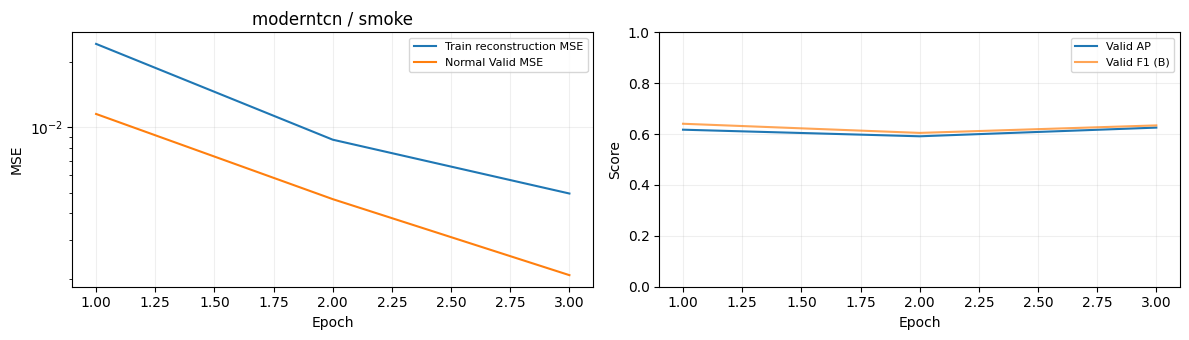

moderntcn trial=smoke epoch=1/3 loss=0.01153753 AP=0.61728 F1_A=0.5786163522012578 F1_B=0.640625 stop=None
moderntcn trial=smoke epoch=3/3 loss=0.002073972 AP=0.62547 F1_A=0.5786163522012578 F1_B=0.6341463414634146 stop=smoke_complete


ap_wait,▁█▁
best_ap_epoch,▁▁█
best_loss_epoch,▁▅█
best_normal_valid_loss,█▃▁
best_valid_ap,▁▁█
checkpoint_logging_backup_seconds,▁▁█
compute_seconds,█▁▁
epoch,▁▁▅▅██
global_step,▁▅█
gpu_peak_bytes,▁██
+43,...


3 epoch 완료. 본학습은 새 가중치에서 시작합니다.
[smoke] 완료 | 27.2초 | /content/drive/MyDrive/KAMP_comparison_v4_validloss_all/moderntcn/moderntcn_validloss_all_20261002T140427Z_42fb396d


In [25]:
if RUN_SMOKE:
    run_stage('smoke')
else:
    print('3 epoch 실행을 건너뜁니다.')


## 실행 3 — 8후보 본학습
각 후보는 최대 800 epoch이며 ASHA 또는 EarlyStopping으로 먼저 종료될 수 있습니다.


[hpo] 시작 | moderntcn | moderntcn_validloss_all_20261002T140427Z_42fb396d


[I 2026-10-02 14:05:19,662] A new study created in RDB with name: moderntcn_validloss_all_20261002T140427Z_42fb396d
/usr/local/lib/python3.13/dist-packages/torch/nn/modules/linear.py:124: UserWarning: Initializing zero-element tensors is a no-op
  init.kaiming_uniform_(self.weight, a=math.sqrt(5))


W&B: https://wandb.ai/Yellow_Mongoose/kamp-predictive-maintenance/runs/moderntcn_validloss_all_20261002T140427Z_42fb396d-trial-0


,후보,epoch,Train MSE,정상 Valid MSE,Valid AP,Valid F1 A,Valid F1 B,학습률,best epoch,종료
0,moderntcn / trial 0,800,0.000011,0.000001,0.585005,0.566038,0.634921,0.000103,787,max_epochs


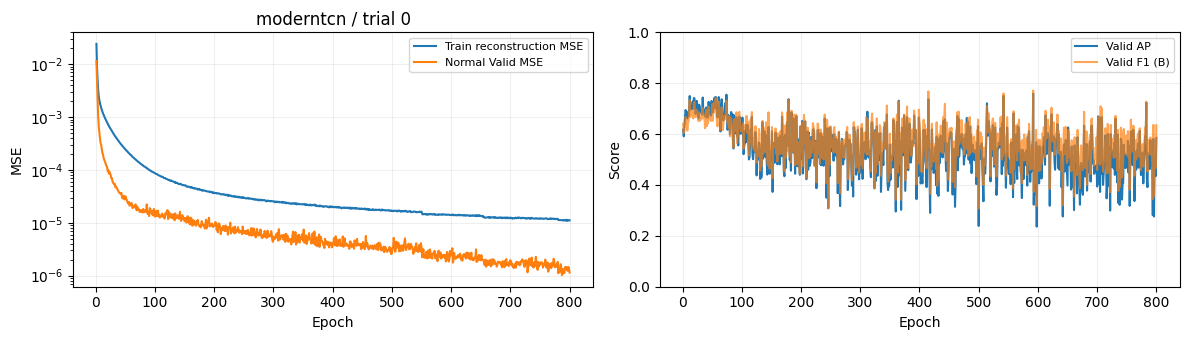

moderntcn trial=0 epoch=1/800 loss=0.01153753 AP=0.61728 F1_A=0.5786163522012578 F1_B=0.640625 stop=None
moderntcn trial=0 epoch=10/800 loss=0.0002530611 AP=0.67096 F1_A=0.6037735849056604 F1_B=0.6474820143884892 stop=None
moderntcn trial=0 epoch=20/800 loss=9.524181e-05 AP=0.74095 F1_A=0.7044025157232704 F1_B=0.7261904761904762 stop=None
moderntcn trial=0 epoch=30/800 loss=5.548508e-05 AP=0.68569 F1_A=0.6415094339622641 F1_B=0.6621621621621622 stop=None
moderntcn trial=0 epoch=40/800 loss=3.66817e-05 AP=0.70463 F1_A=0.6666666666666666 F1_B=0.6956521739130435 stop=None
moderntcn trial=0 epoch=50/800 loss=3.177623e-05 AP=0.70713 F1_A=0.6918238993710691 F1_B=0.7183098591549296 stop=None
moderntcn trial=0 epoch=60/800 loss=2.386123e-05 AP=0.69367 F1_A=0.6792452830188679 F1_B=0.6792452830188679 stop=None
moderntcn trial=0 epoch=70/800 loss=2.016484e-05 AP=0.66188 F1_A=0.6037735849056604 F1_B=0.6714285714285714 stop=None
moderntcn trial=0 epoch=80/800 loss=1.828952e-05 AP=0.59981 F1_A=0.591

ap_wait,▁▂▂▁▁▂▂▂▂▃▃▄▄▄▄▄▄▅▅▅▆▆▆▆▇▇▇███▁▂▂▃▃▃▃▃▄▄
best_ap_epoch,▁▁▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂███████████
best_loss_epoch,▁▁▁▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▄▄▅▅▅▅▅▅▅▅▅▆▆▆▆▆▇█████
best_normal_valid_loss,█▇▅▅▅▄▄▄▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_valid_ap,▁▃▇▇▇███████████████████████████████████
checkpoint_logging_backup_seconds,▂▁▃▁▁▂▁▂▂▃▂▄▃▄▄▄▄▅▅▅▅▅▅▆▅▅▅▅▆▆▆█▇██▇████
compute_seconds,▃▂▄▄▆▃▂▂▄▁█▄▅▄▃▆▄▄▃▂▂▅▃▃▆▁▂▂▂▂▃▄▄▅▂▇▅▃▂▅
epoch,▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▅▅▅▅▅▅▅▅▆▆▆▆▆▆▆▆▆▇▇████
global_step,▁▁▂▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇███
gpu_peak_bytes,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+44,...


,trial,state,best Normal Valid MSE,best epoch,종료 epoch,종료 이유,learning_rate,dropout,revin
0,0,COMPLETE,0.000001,787,800,max_epochs,0.0003,0.1,True


/usr/local/lib/python3.13/dist-packages/torch/nn/modules/linear.py:124: UserWarning: Initializing zero-element tensors is a no-op
  init.kaiming_uniform_(self.weight, a=math.sqrt(5))


W&B: https://wandb.ai/Yellow_Mongoose/kamp-predictive-maintenance/runs/moderntcn_validloss_all_20261002T140427Z_42fb396d-trial-1


,후보,epoch,Train MSE,정상 Valid MSE,Valid AP,Valid F1 A,Valid F1 B,학습률,best epoch,종료
0,moderntcn / trial 1,50,0.000163,0.000129,0.828511,0.779874,0.832117,0.000056,46,asha


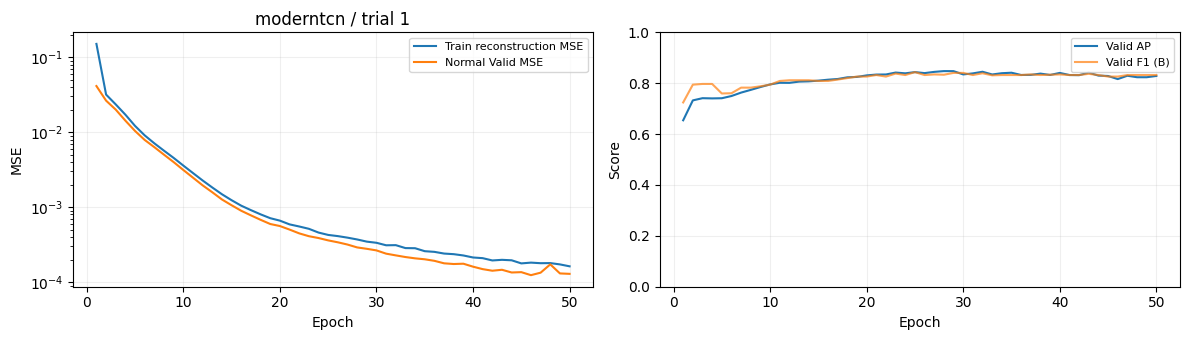

moderntcn trial=1 epoch=1/800 loss=0.04130548 AP=0.65422 F1_A=0.6289308176100629 F1_B=0.7244094488188977 stop=None
moderntcn trial=1 epoch=10/800 loss=0.003136009 AP=0.79516 F1_A=0.7169811320754716 F1_B=0.7943262411347518 stop=None
moderntcn trial=1 epoch=20/800 loss=0.0005611181 AP=0.83076 F1_A=0.779874213836478 F1_B=0.8260869565217391 stop=None
moderntcn trial=1 epoch=30/800 loss=0.0002656045 AP=0.83455 F1_A=0.779874213836478 F1_B=0.8405797101449275 stop=None
moderntcn trial=1 epoch=40/800 loss=0.0001611669 AP=0.84047 F1_A=0.779874213836478 F1_B=0.8345323741007195 stop=None
moderntcn trial=1 epoch=50/800 loss=0.0001292869 AP=0.82851 F1_A=0.779874213836478 F1_B=0.8321167883211679 stop=asha


ap_wait,▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▃▃▃▄▄▅▅▅▅▆▆▇▇▇█
best_ap_epoch,▁▁▂▂▂▃▃▃▃▄▄▄▅▅▆▆▆▇▇▇████████████████████
best_loss_epoch,▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇█████
best_normal_valid_loss,█▅▄▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_valid_ap,▁▄▄▄▄▅▅▆▆▆▇▇▇▇▇▇▇███████████████████████
checkpoint_logging_backup_seconds,▇▆▇▃▅█▇▆▇▆█▆▆▅▆▆▇▆▇▄▄▅▆▃▃▄▄▄▄▄▁▆▄▃▁▂▄▁▁▃
compute_seconds,▇▇▃▂▇▃▇▃▃▂█▆▂▆▂▃▅█▁▃▄▅▃▅▁▆▄▁▃▅▆█▂▆▂▆█▂▅▁
epoch,▁▁▁▁▁▂▂▂▂▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇████
global_step,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
gpu_peak_bytes,▁███████████████████████████████████████
+44,...


,trial,state,best Normal Valid MSE,best epoch,종료 epoch,종료 이유,learning_rate,dropout,revin
0,0,COMPLETE,0.000001,787,800,max_epochs,0.000300,0.1,True
1,1,PRUNED,0.000124,46,50,asha,0.000056,0.0,False


/usr/local/lib/python3.13/dist-packages/torch/nn/modules/linear.py:124: UserWarning: Initializing zero-element tensors is a no-op
  init.kaiming_uniform_(self.weight, a=math.sqrt(5))


W&B: https://wandb.ai/Yellow_Mongoose/kamp-predictive-maintenance/runs/moderntcn_validloss_all_20261002T140427Z_42fb396d-trial-2


,후보,epoch,Train MSE,정상 Valid MSE,Valid AP,Valid F1 A,Valid F1 B,학습률,best epoch,종료
0,moderntcn / trial 2,50,0.001581,0.001473,0.722882,0.679245,0.720588,0.000013,50,asha


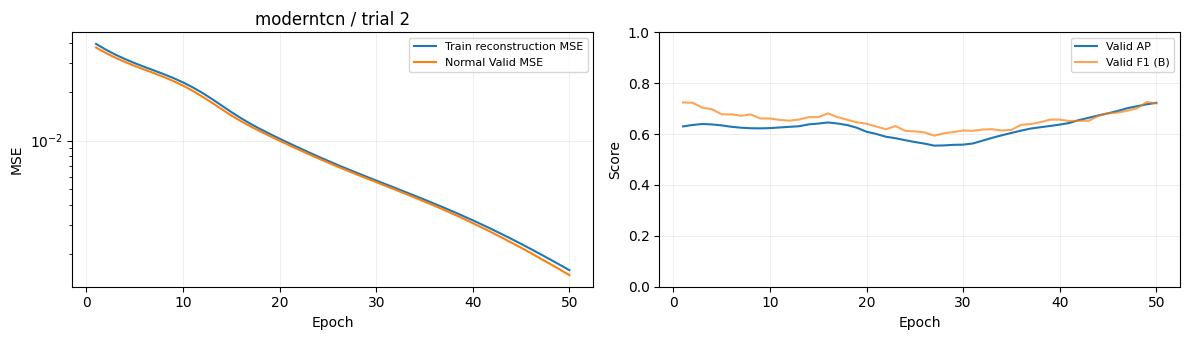

moderntcn trial=2 epoch=1/800 loss=0.03762133 AP=0.63013 F1_A=0.5911949685534591 F1_B=0.7244094488188977 stop=None
moderntcn trial=2 epoch=10/800 loss=0.02189203 AP=0.62351 F1_A=0.5660377358490566 F1_B=0.6612903225806451 stop=None
moderntcn trial=2 epoch=20/800 loss=0.009984569 AP=0.60918 F1_A=0.5534591194968553 F1_B=0.640625 stop=None
moderntcn trial=2 epoch=30/800 loss=0.005535662 AP=0.55857 F1_A=0.5031446540880503 F1_B=0.6141732283464567 stop=None
moderntcn trial=2 epoch=40/800 loss=0.003086956 AP=0.63727 F1_A=0.5786163522012578 F1_B=0.656934306569343 stop=None
moderntcn trial=2 epoch=50/800 loss=0.00147265 AP=0.72288 F1_A=0.6792452830188679 F1_B=0.7205882352941176 stop=asha


ap_wait,▁▁▁▁▂▂▂▃▃▃▄▄▁▁▁▂▂▂▃▃▄▄▄▄▅▅▅▆▆▆▇██▁▁▁▁▁▁▁
best_ap_epoch,▁▁▁▁▁▁▁▁▁▁▁▁▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▇▇▇███
best_loss_epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
best_normal_valid_loss,█▇▇▇▆▆▆▅▅▅▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
best_valid_ap,▁▁▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▃▅▆▆▇█
checkpoint_logging_backup_seconds,▃▅▅▁▃▂▅▁▃▃▄▂▇▆▂▂▃▃▂▂▃▂▃▂▂▃▃▃▄▃▃▃▃▃▆▆▇▇▆█
compute_seconds,▃▃▃▄▂▁▂▃▃▅▃▂▄▆▄▁▃▄▆▅▃▃█▅▂▂▃▂▂▃▃▂▅▄▃▃▃▄▇▄
epoch,▁▁▁▁▁▂▂▂▃▃▃▃▃▃▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇███
global_step,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇███
gpu_peak_bytes,▁███████████████████████████████████████
+44,...


,trial,state,best Normal Valid MSE,best epoch,종료 epoch,종료 이유,learning_rate,dropout,revin
0,0,COMPLETE,0.000001,787,800,max_epochs,0.000300,0.1,True
1,1,PRUNED,0.000124,46,50,asha,0.000056,0.0,False
2,2,PRUNED,0.001473,50,50,asha,0.000013,0.0,True


/usr/local/lib/python3.13/dist-packages/torch/nn/modules/linear.py:124: UserWarning: Initializing zero-element tensors is a no-op
  init.kaiming_uniform_(self.weight, a=math.sqrt(5))


W&B: https://wandb.ai/Yellow_Mongoose/kamp-predictive-maintenance/runs/moderntcn_validloss_all_20261002T140427Z_42fb396d-trial-3


,후보,epoch,Train MSE,정상 Valid MSE,Valid AP,Valid F1 A,Valid F1 B,학습률,best epoch,종료
0,moderntcn / trial 3,800,0.000001,9.623091e-07,0.816301,0.767296,0.783784,0.000111,783,max_epochs


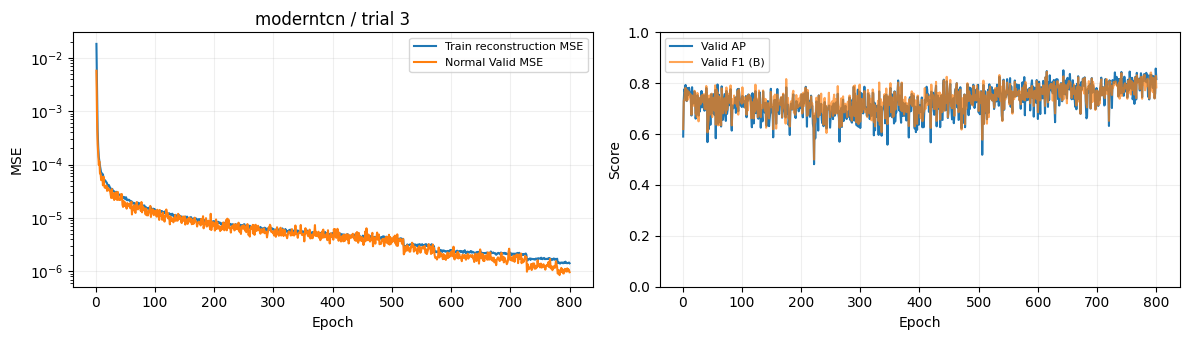

moderntcn trial=3 epoch=1/800 loss=0.005707274 AP=0.59022 F1_A=0.5660377358490566 F1_B=0.6197183098591549 stop=None
moderntcn trial=3 epoch=10/800 loss=5.669952e-05 AP=0.76050 F1_A=0.7169811320754716 F1_B=0.7605633802816901 stop=None
moderntcn trial=3 epoch=20/800 loss=3.384226e-05 AP=0.76778 F1_A=0.7044025157232704 F1_B=0.7703703703703704 stop=None
moderntcn trial=3 epoch=30/800 loss=2.887894e-05 AP=0.70776 F1_A=0.6792452830188679 F1_B=0.7164179104477612 stop=None
moderntcn trial=3 epoch=40/800 loss=2.213191e-05 AP=0.78107 F1_A=0.7421383647798742 F1_B=0.7891156462585034 stop=None
moderntcn trial=3 epoch=50/800 loss=1.66492e-05 AP=0.68169 F1_A=0.6289308176100629 F1_B=0.6666666666666666 stop=None
moderntcn trial=3 epoch=60/800 loss=2.00749e-05 AP=0.63965 F1_A=0.5786163522012578 F1_B=0.6341463414634146 stop=None
moderntcn trial=3 epoch=70/800 loss=1.544837e-05 AP=0.73974 F1_A=0.7295597484276729 F1_B=0.7295597484276729 stop=None
moderntcn trial=3 epoch=80/800 loss=1.595066e-05 AP=0.71305 

ap_wait,▁▁▁▁▁▂▁▁▂▂▄▄▄▆▆▇▇▇██▁▂▂▂▃▂▃▄▂▂▃▁▁▂▁▂▃▅▅▅
best_ap_epoch,▁▂▂▂▂▂▂▂▂▂▂▂▂▂▂▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇████████
best_loss_epoch,▁▁▁▁▁▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▇▇▇▇▇▇▇▇▇▇▇██
best_normal_valid_loss,█▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_valid_ap,▁▁▁▁▁▁▁▁▁▁▁▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅██████████████
checkpoint_logging_backup_seconds,▄▁▁▂▁▂▂▂▂▂▂▂▂▃▄▃▃▃▃▃▃▄▄▄▅▅▅▅▆▅▆▆▆▆▆▇▆▇▇█
compute_seconds,▃▃▄▁▃▂▂▂▄▃▄▅▄▄▁█▄▃▂▃▃▁▆▄▂▄▆▂▂▃▃▃▃▆▁▂▅█▂▂
epoch,▁▁▁▁▁▃▃▃▃▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▅▅▅▆▆▆▇▇▇▇▇█
global_step,▁▁▁▂▂▂▂▂▂▂▃▃▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇███
gpu_peak_bytes,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+44,...


,trial,state,best Normal Valid MSE,best epoch,종료 epoch,종료 이유,learning_rate,dropout,revin
0,0,COMPLETE,1.022476e-06,787,800,max_epochs,0.000300,0.1,True
1,1,PRUNED,1.241984e-04,46,50,asha,0.000056,0.0,False
2,2,PRUNED,1.472650e-03,50,50,asha,0.000013,0.0,True
3,3,COMPLETE,8.473101e-07,783,800,max_epochs,0.000462,0.0,True


/usr/local/lib/python3.13/dist-packages/torch/nn/modules/linear.py:124: UserWarning: Initializing zero-element tensors is a no-op
  init.kaiming_uniform_(self.weight, a=math.sqrt(5))


W&B: https://wandb.ai/Yellow_Mongoose/kamp-predictive-maintenance/runs/moderntcn_validloss_all_20261002T140427Z_42fb396d-trial-4


,후보,epoch,Train MSE,정상 Valid MSE,Valid AP,Valid F1 A,Valid F1 B,학습률,best epoch,종료
0,moderntcn / trial 4,50,0.000155,0.000045,0.559018,0.553459,0.577181,0.000904,50,asha


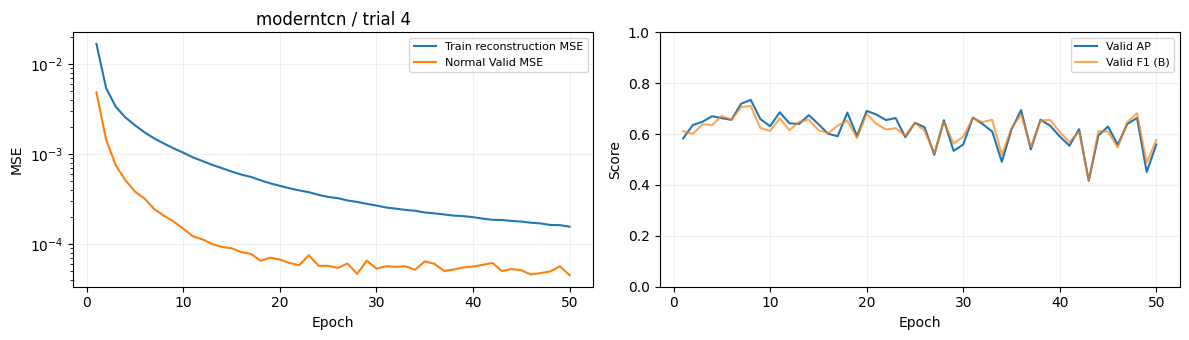

moderntcn trial=4 epoch=1/800 loss=0.004844132 AP=0.58319 F1_A=0.5408805031446541 F1_B=0.6115702479338843 stop=None
moderntcn trial=4 epoch=10/800 loss=0.0001471168 AP=0.63096 F1_A=0.6037735849056604 F1_B=0.6125 stop=None
moderntcn trial=4 epoch=20/800 loss=6.694128e-05 AP=0.69120 F1_A=0.6540880503144654 F1_B=0.68 stop=None
moderntcn trial=4 epoch=30/800 loss=5.305692e-05 AP=0.55901 F1_A=0.49056603773584906 F1_B=0.5901639344262295 stop=None
moderntcn trial=4 epoch=40/800 loss=5.598649e-05 AP=0.59062 F1_A=0.5534591194968553 F1_B=0.608 stop=None
moderntcn trial=4 epoch=50/800 loss=4.489596e-05 AP=0.55902 F1_A=0.5534591194968553 F1_B=0.5771812080536913 stop=asha


ap_wait,▁▁▁▁▁▁▁▁▁▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇██
best_ap_epoch,▁▂▃▄▄▇██████████████████████████████████
best_loss_epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▇▇▇█
best_normal_valid_loss,█▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_valid_ap,▁▃▄▅▅▇██████████████████████████████████
checkpoint_logging_backup_seconds,▅▆▆▇▃█▆▄▄▄▄▅▄▇▄▂▂▄▄▁▅▂▄▁▁▂▁▁▃▁▁▁▂▂▂▃▅▂▁▆
compute_seconds,▄▃▃▃▆▃▃▃█▂▃▃▂▃▃▃▄▄▄▃▂▂▆▅▁▃▃▅▅▄▃▃▅▂▄▅▅▄▂▃
epoch,▁▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇██
global_step,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
gpu_peak_bytes,▁███████████████████████████████████████
+44,...


,trial,state,best Normal Valid MSE,best epoch,종료 epoch,종료 이유,learning_rate,dropout,revin
0,0,COMPLETE,1.022476e-06,787,800,max_epochs,0.000300,0.1,True
1,1,PRUNED,1.241984e-04,46,50,asha,0.000056,0.0,False
2,2,PRUNED,1.472650e-03,50,50,asha,0.000013,0.0,True
3,3,COMPLETE,8.473101e-07,783,800,max_epochs,0.000462,0.0,True
4,4,PRUNED,4.489596e-05,50,50,asha,0.000904,0.2,True


/usr/local/lib/python3.13/dist-packages/torch/nn/modules/linear.py:124: UserWarning: Initializing zero-element tensors is a no-op
  init.kaiming_uniform_(self.weight, a=math.sqrt(5))


W&B: https://wandb.ai/Yellow_Mongoose/kamp-predictive-maintenance/runs/moderntcn_validloss_all_20261002T140427Z_42fb396d-trial-5


,후보,epoch,Train MSE,정상 Valid MSE,Valid AP,Valid F1 A,Valid F1 B,학습률,best epoch,종료
0,moderntcn / trial 5,50,0.000091,0.000067,0.813045,0.754717,0.834532,0.00022,44,asha


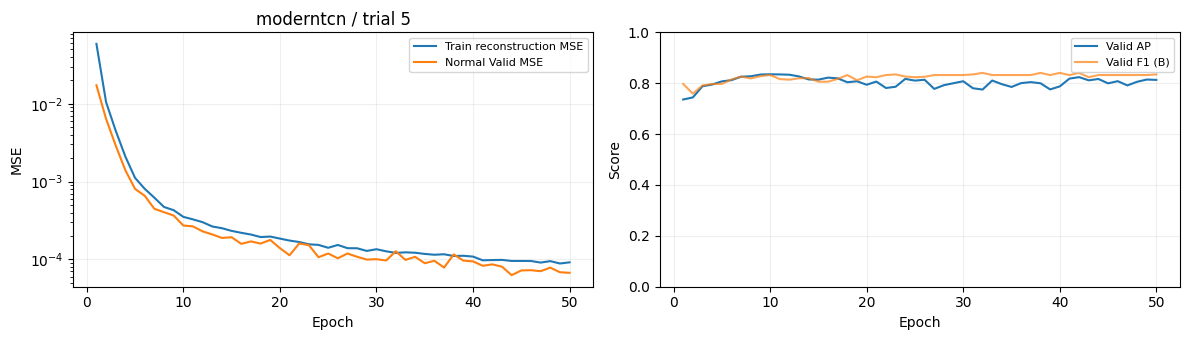

moderntcn trial=5 epoch=1/800 loss=0.01730859 AP=0.73593 F1_A=0.6918238993710691 F1_B=0.7971014492753623 stop=None
moderntcn trial=5 epoch=10/800 loss=0.0002722092 AP=0.83506 F1_A=0.7924528301886793 F1_B=0.8322147651006712 stop=None
moderntcn trial=5 epoch=20/800 loss=0.0001391686 AP=0.79388 F1_A=0.7421383647798742 F1_B=0.8260869565217391 stop=None
moderntcn trial=5 epoch=30/800 loss=0.0001003555 AP=0.80780 F1_A=0.7547169811320755 F1_B=0.8321167883211679 stop=None
moderntcn trial=5 epoch=40/800 loss=9.406849e-05 AP=0.78745 F1_A=0.7547169811320755 F1_B=0.8405797101449275 stop=None
moderntcn trial=5 epoch=50/800 loss=6.705293e-05 AP=0.81304 F1_A=0.7547169811320755 F1_B=0.8345323741007195 stop=asha


ap_wait,▁▁▁▁▁▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▇▇▇▇▇██
best_ap_epoch,▁▂▃▃▄▆▆▇████████████████████████████████
best_loss_epoch,▁▁▁▁▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇█████
best_normal_valid_loss,█▄▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_valid_ap,▁▂▅▅▆▇▇█████████████████████████████████
checkpoint_logging_backup_seconds,▆▇▇█▆█▇█▇▄▅▄▁▄▁▁▃▄▁▃▄▂▅▃▄▃▁▅▂▄▂▂▂▃▁▂▂▂▄▃
compute_seconds,▃▂▅▂▂▁▃▂▂▂▂▂▁▂█▁▃▃▃▄▂▃▂▃▄▃▃▂█▆▁▅▅▇▄▄▃▆▇▁
epoch,▁▁▁▁▂▂▂▂▃▃▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▆▆▆▆▆▇▇▇▇▇▇████
global_step,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇██
gpu_peak_bytes,▁███████████████████████████████████████
+44,...


,trial,state,best Normal Valid MSE,best epoch,종료 epoch,종료 이유,learning_rate,dropout,revin
0,0,COMPLETE,1.022476e-06,787,800,max_epochs,0.000300,0.1,True
1,1,PRUNED,1.241984e-04,46,50,asha,0.000056,0.0,False
2,2,PRUNED,1.472650e-03,50,50,asha,0.000013,0.0,True
3,3,COMPLETE,8.473101e-07,783,800,max_epochs,0.000462,0.0,True
4,4,PRUNED,4.489596e-05,50,50,asha,0.000904,0.2,True
5,5,PRUNED,6.256784e-05,44,50,asha,0.000220,0.0,False


/usr/local/lib/python3.13/dist-packages/torch/nn/modules/linear.py:124: UserWarning: Initializing zero-element tensors is a no-op
  init.kaiming_uniform_(self.weight, a=math.sqrt(5))


W&B: https://wandb.ai/Yellow_Mongoose/kamp-predictive-maintenance/runs/moderntcn_validloss_all_20261002T140427Z_42fb396d-trial-6


,후보,epoch,Train MSE,정상 Valid MSE,Valid AP,Valid F1 A,Valid F1 B,학습률,best epoch,종료
0,moderntcn / trial 6,800,0.000007,5.475005e-07,0.443293,0.490566,0.505747,0.000103,760,max_epochs


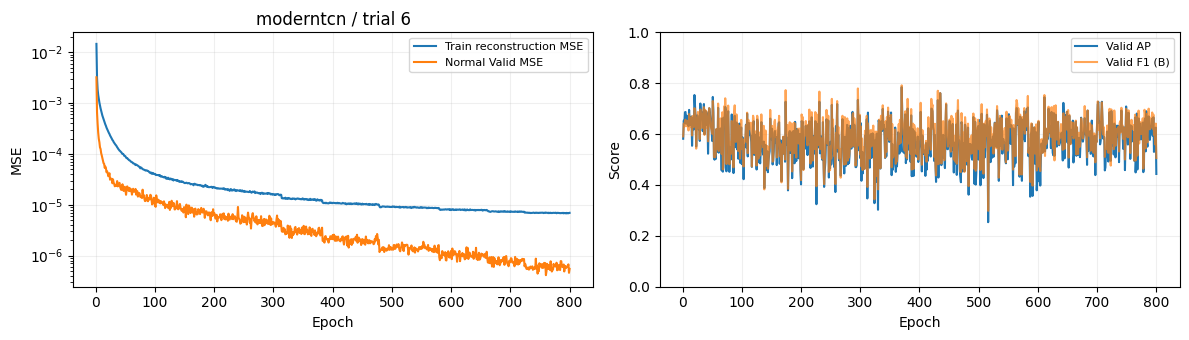

moderntcn trial=6 epoch=1/800 loss=0.003214198 AP=0.58170 F1_A=0.5283018867924528 F1_B=0.5909090909090909 stop=None
moderntcn trial=6 epoch=10/800 loss=9.338819e-05 AP=0.63075 F1_A=0.5660377358490566 F1_B=0.6142857142857143 stop=None
moderntcn trial=6 epoch=20/800 loss=4.220371e-05 AP=0.75367 F1_A=0.6918238993710691 F1_B=0.7019867549668874 stop=None
moderntcn trial=6 epoch=30/800 loss=2.726436e-05 AP=0.72021 F1_A=0.6918238993710691 F1_B=0.6967741935483871 stop=None
moderntcn trial=6 epoch=40/800 loss=2.695819e-05 AP=0.68784 F1_A=0.6540880503144654 F1_B=0.6906474820143885 stop=None
moderntcn trial=6 epoch=50/800 loss=1.922694e-05 AP=0.57277 F1_A=0.5786163522012578 F1_B=0.6013986013986014 stop=None
moderntcn trial=6 epoch=60/800 loss=1.993985e-05 AP=0.70311 F1_A=0.6415094339622641 F1_B=0.72 stop=None
moderntcn trial=6 epoch=70/800 loss=1.859027e-05 AP=0.66492 F1_A=0.6037735849056604 F1_B=0.7086614173228346 stop=None
moderntcn trial=6 epoch=80/800 loss=1.480875e-05 AP=0.54951 F1_A=0.51572

ap_wait,▂▂▃▄▄▄▄▅▅▆▆▆▆▇▇▇▇▁▁▁▂▂▃▃▄▄▄▄▅▅▆▆▆▆▆▇▇███
best_ap_epoch,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁█████████████████████████
best_loss_epoch,▁▁▁▂▂▂▂▂▂▂▂▃▃▃▃▃▃▃▃▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇▇█████
best_normal_valid_loss,█▅▅▅▄▄▄▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_valid_ap,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁███████████████████████
checkpoint_logging_backup_seconds,▁▂▂▂▂▂▂▂▂▂▂▂▃▂▂▅▃▃▃▃▃▅▃▃▃▄▄▄▄▅▅▅▅▅▅▅█▆▆▇
compute_seconds,▅▃▂▂▂▅▄▆▆█▆▄▅▅▄▂▅▅▃▅▄▂▅▃▄▄▆▃▂▅▃▂▃▄▆▁▄▅▂▅
epoch,▁▁▁▁▁▂▂▂▂▃▄▄▄▄▄▅▅▅▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇████
global_step,▁▁▁▁▁▂▂▃▃▃▃▃▃▃▄▄▄▄▄▄▄▄▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇█
gpu_peak_bytes,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+44,...


,trial,state,best Normal Valid MSE,best epoch,종료 epoch,종료 이유,learning_rate,dropout,revin
0,0,COMPLETE,1.022476e-06,787,800,max_epochs,0.000300,0.1,True
1,1,PRUNED,1.241984e-04,46,50,asha,0.000056,0.0,False
2,2,PRUNED,1.472650e-03,50,50,asha,0.000013,0.0,True
3,3,COMPLETE,8.473101e-07,783,800,max_epochs,0.000462,0.0,True
4,4,PRUNED,4.489596e-05,50,50,asha,0.000904,0.2,True
5,5,PRUNED,6.256784e-05,44,50,asha,0.000220,0.0,False
6,6,COMPLETE,4.123514e-07,760,800,max_epochs,0.000876,0.1,True


/usr/local/lib/python3.13/dist-packages/torch/nn/modules/linear.py:124: UserWarning: Initializing zero-element tensors is a no-op
  init.kaiming_uniform_(self.weight, a=math.sqrt(5))


W&B: https://wandb.ai/Yellow_Mongoose/kamp-predictive-maintenance/runs/moderntcn_validloss_all_20261002T140427Z_42fb396d-trial-7


,후보,epoch,Train MSE,정상 Valid MSE,Valid AP,Valid F1 A,Valid F1 B,학습률,best epoch,종료
0,moderntcn / trial 7,50,0.001202,0.00021,0.717643,0.679245,0.698795,0.000057,50,asha


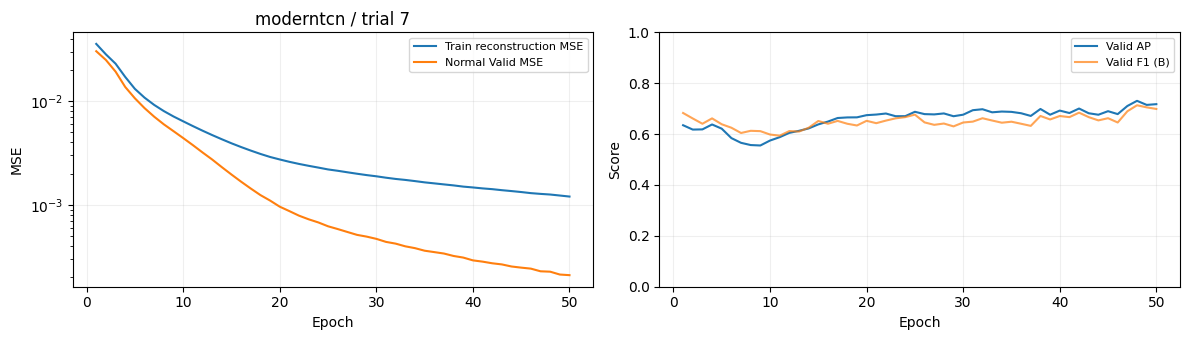

moderntcn trial=7 epoch=1/800 loss=0.0302996 AP=0.63484 F1_A=0.6037735849056604 F1_B=0.6829268292682927 stop=None
moderntcn trial=7 epoch=10/800 loss=0.004406774 AP=0.57463 F1_A=0.5283018867924528 F1_B=0.5982905982905983 stop=None
moderntcn trial=7 epoch=20/800 loss=0.0009598436 AP=0.67440 F1_A=0.6289308176100629 F1_B=0.6521739130434783 stop=None
moderntcn trial=7 epoch=30/800 loss=0.0004699211 AP=0.67626 F1_A=0.6415094339622641 F1_B=0.6455696202531646 stop=None
moderntcn trial=7 epoch=40/800 loss=0.0002914071 AP=0.69239 F1_A=0.6540880503144654 F1_B=0.6710526315789473 stop=None
moderntcn trial=7 epoch=50/800 loss=0.0002098542 AP=0.71764 F1_A=0.6792452830188679 F1_B=0.6987951807228916 stop=asha


ap_wait,▁▂▂▁▂▃▄▅▅▆█▁▁▁▁▁▁▁▂▂▂▂▃▄▅▁▂▂▃▄▁▂▂▃▁▂▃▄▁▂
best_ap_epoch,▁▁▁▁▁▁▁▁▁▁▁▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇███
best_loss_epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
best_normal_valid_loss,█▇▅▄▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_valid_ap,▁▁▁▁▁▁▁▁▁▁▁▁▂▃▃▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▆▆▆▆▆▆▇██
checkpoint_logging_backup_seconds,█▄▁▅▁▂▃▁▁▄▆▁▆▅▅▆█▅▅▁▂▂▂▂▄▂▃▂▃▄▃▂▁▇▂▂▂▅▆▄
compute_seconds,▃▅▃▃▂▃▅▄▂▁▇▆▃▃▇▄▄▄▄█▄▄▃▁▂▃▁▁▃▄▅▃▁▃▃▅▂▆▁▅
epoch,▁▁▁▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▇▇▇▇▇▇████
global_step,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
gpu_peak_bytes,▁███████████████████████████████████████
+44,...


,trial,state,best Normal Valid MSE,best epoch,종료 epoch,종료 이유,learning_rate,dropout,revin
0,0,COMPLETE,1.022476e-06,787,800,max_epochs,0.000300,0.1,True
1,1,PRUNED,1.241984e-04,46,50,asha,0.000056,0.0,False
2,2,PRUNED,1.472650e-03,50,50,asha,0.000013,0.0,True
3,3,COMPLETE,8.473101e-07,783,800,max_epochs,0.000462,0.0,True
4,4,PRUNED,4.489596e-05,50,50,asha,0.000904,0.2,True
5,5,PRUNED,6.256784e-05,44,50,asha,0.000220,0.0,False
6,6,COMPLETE,4.123514e-07,760,800,max_epochs,0.000876,0.1,True
7,7,PRUNED,2.098542e-04,50,50,asha,0.000057,0.1,True


Selection frozen: {
  "model": "moderntcn",
  "trial_number": 6,
  "params": {
    "learning_rate": 0.000875933501878354,
    "dropout": 0.1,
    "revin": true
  },
  "objective": "min normal_valid_loss among COMPLETE",
  "value": 4.123514304648599e-07,
  "primary_checkpoint": "best_normal_val_loss",
  "primary_policy": "guide_pr_equal",
  "checkpoints": {
    "best_normal_val_loss": {
      "epoch": 760
    },
    "best_valid_ap": {
      "epoch": 370
    },
    "last": {
      "epoch": 800
    }
  },
  "hpo_current_session_seconds": 5937.167966868999,
  "test_previously_seen": true
}
[hpo] 완료 | 5939.5초 | /content/drive/MyDrive/KAMP_comparison_v4_validloss_all/moderntcn/moderntcn_validloss_all_20261002T140427Z_42fb396d


,number,value,datetime_start,datetime_complete,duration,params_dropout,params_learning_rate,params_revin,user_attrs_summary,system_attrs_completed_rung_0,system_attrs_completed_rung_1,system_attrs_completed_rung_2,system_attrs_completed_rung_3,system_attrs_fixed_params,state
0,0,1.022476e-06,2026-10-02 14:05:19.701230,2026-10-02 14:35:44.867487,0 days 00:30:25.166257,0.1,0.000300,True,"{'epoch': 800, 'best_loss': 1.0224763626716992...",0.000028,0.000013,0.000008,0.000003,"{'learning_rate': 0.0003, 'dropout': 0.1, 'rev...",COMPLETE
1,1,1.241984e-04,2026-10-02 14:35:45.029137,2026-10-02 14:37:36.907905,0 days 00:01:51.878768,0.0,0.000056,False,"{'epoch': 50, 'best_loss': 0.00012419835533016...",0.000124,NaN,NaN,NaN,NaN,PRUNED
2,2,1.472650e-03,2026-10-02 14:37:37.048498,2026-10-02 14:39:30.425246,0 days 00:01:53.376748,0.0,0.000013,True,"{'epoch': 50, 'best_loss': 0.00147264952810996...",0.001473,NaN,NaN,NaN,NaN,PRUNED
3,3,8.473101e-07,2026-10-02 14:39:30.553322,2026-10-02 15:08:17.275180,0 days 00:28:46.721858,0.0,0.000462,True,"{'epoch': 800, 'best_loss': 8.473100535904046e...",0.000016,0.000010,0.000006,0.000003,NaN,COMPLETE
4,4,4.489596e-05,2026-10-02 15:08:17.436182,2026-10-02 15:10:15.251950,0 days 00:01:57.815768,0.2,0.000904,True,"{'epoch': 50, 'best_loss': 4.4895961670416466e...",0.000045,NaN,NaN,NaN,NaN,PRUNED
5,5,6.256784e-05,2026-10-02 15:10:15.392070,2026-10-02 15:12:06.739856,0 days 00:01:51.347786,0.0,0.000220,False,"{'epoch': 50, 'best_loss': 6.256783703684824e-...",0.000063,NaN,NaN,NaN,NaN,PRUNED
6,6,4.123514e-07,2026-10-02 15:12:06.867059,2026-10-02 15:42:17.156752,0 days 00:30:10.289693,0.1,0.000876,True,"{'epoch': 800, 'best_loss': 4.123514304648599e...",0.000019,0.000010,0.000005,0.000002,NaN,COMPLETE
7,7,2.098542e-04,2026-10-02 15:42:17.320547,2026-10-02 15:44:16.613999,0 days 00:01:59.293452,0.1,0.000057,True,"{'epoch': 50, 'best_loss': 0.00020985415025608...",0.000210,NaN,NaN,NaN,NaN,PRUNED


{
  "model": "moderntcn",
  "trial_number": 6,
  "params": {
    "learning_rate": 0.000875933501878354,
    "dropout": 0.1,
    "revin": true
  },
  "objective": "min normal_valid_loss among COMPLETE",
  "value": 4.123514304648599e-07,
  "primary_checkpoint": "best_normal_val_loss",
  "primary_policy": "guide_pr_equal",
  "checkpoints": {
    "best_normal_val_loss": {
      "epoch": 760
    },
    "best_valid_ap": {
      "epoch": 370
    },
    "last": {
      "epoch": 800
    }
  },
  "hpo_current_session_seconds": 5937.167966868999,
  "test_previously_seen": true
}


In [26]:
run_stage('hpo')
display(pd.read_csv(OUTPUT_DIR/'trials_summary.csv'))
print((OUTPUT_DIR/'selection.json').read_text())


## 실행 4 — 고정된 후보의 Test 평가


In [27]:
run_stage('test')
comparison = pd.read_csv(OUTPUT_DIR/'test/comparison.csv')
display(comparison)


[test] 시작 | moderntcn | moderntcn_validloss_all_20261002T140427Z_42fb396d


/usr/local/lib/python3.13/dist-packages/torch/nn/modules/linear.py:124: UserWarning: Initializing zero-element tensors is a no-op
  init.kaiming_uniform_(self.weight, a=math.sqrt(5))


W&B: https://wandb.ai/Yellow_Mongoose/kamp-predictive-maintenance/runs/moderntcn_validloss_all_20261002T140427Z_42fb396d-test-6


wandb: Adding directory to artifact (/content/KAMP_v4_runs/moderntcn_validloss_all_20261002T140427Z_42fb396d/final_candidate)... Done. 0.0s


epoch,▁▁▁▁▁▁▁▁▁▁▁
best_normal_val_loss/guide_pr_equal/test_accuracy,0.96442
best_normal_val_loss/guide_pr_equal/test_ap,0.71122
best_normal_val_loss/guide_pr_equal/test_available,True
best_normal_val_loss/guide_pr_equal/test_f1,0.66816
best_normal_val_loss/guide_pr_equal/test_fn,131
best_normal_val_loss/guide_pr_equal/test_fnr,0.46786
best_normal_val_loss/guide_pr_equal/test_fp,17
best_normal_val_loss/guide_pr_equal/test_fpr,0.00438
best_normal_val_loss/guide_pr_equal/test_precision,0.89759
best_normal_val_loss/guide_pr_equal/test_recall,0.53214


    model                       protocol  trial           checkpoint  epoch         policy  primary  normal_valid_loss  valid_ap  test_ap  test_roc_auc  test_threshold  test_available  test_accuracy  test_precision  test_recall  test_f1  test_tp  test_tn  test_fp  test_fn  test_fpr  test_fnr  inference_b1_ms_batch  inference_b1_ms_window  inference_b128_ms_batch  inference_b128_ms_window  parameters  weight_bytes
moderntcn moderntcn_hpo_v4_validloss_all      6 best_normal_val_loss    760 guide_pr_equal     True       4.123514e-07  0.578026 0.711218      0.903862        0.000003            True       0.964423        0.897590     0.532143 0.668161      149     3863       17      131  0.004381  0.467857               3.468871                3.468871                 3.721182                  0.029072      378504       1563736
moderntcn moderntcn_hpo_v4_validloss_all      6 best_normal_val_loss    760   valid_max_f1    False       4.123514e-07  0.578026 0.711218      0.903862        0.00000

,model,protocol,trial,checkpoint,epoch,policy,primary,normal_valid_loss,valid_ap,test_ap,...,test_fp,test_fn,test_fpr,test_fnr,inference_b1_ms_batch,inference_b1_ms_window,inference_b128_ms_batch,inference_b128_ms_window,parameters,weight_bytes
0,moderntcn,moderntcn_hpo_v4_validloss_all,6,best_normal_val_loss,760,guide_pr_equal,True,4.123514e-07,0.578026,0.711218,...,17,131,0.004381,0.467857,3.468871,3.468871,3.721182,0.029072,378504,1563736
1,moderntcn,moderntcn_hpo_v4_validloss_all,6,best_normal_val_loss,760,valid_max_f1,False,4.123514e-07,0.578026,0.711218,...,10,135,0.002577,0.482143,3.468871,3.468871,3.721182,0.029072,378504,1563736
2,moderntcn,moderntcn_hpo_v4_validloss_all,6,best_valid_ap,370,guide_pr_equal,False,3.133503e-06,0.784528,0.806080,...,9,115,0.002320,0.410714,3.483671,3.483671,3.784056,0.029563,378504,1563127
3,moderntcn,moderntcn_hpo_v4_validloss_all,6,best_valid_ap,370,valid_max_f1,False,3.133503e-06,0.784528,0.806080,...,5,118,0.001289,0.421429,3.483671,3.483671,3.784056,0.029563,378504,1563127
4,moderntcn,moderntcn_hpo_v4_validloss_all,6,last,800,guide_pr_equal,False,5.475005e-07,0.443293,0.669238,...,21,155,0.005412,0.553571,3.482748,3.482748,3.679145,0.028743,378504,1562152
5,moderntcn,moderntcn_hpo_v4_validloss_all,6,last,800,valid_max_f1,False,5.475005e-07,0.443293,0.669238,...,29,147,0.007474,0.525000,3.482748,3.482748,3.679145,0.028743,378504,1562152


## 실행 5 — 그래프와 결과 위치


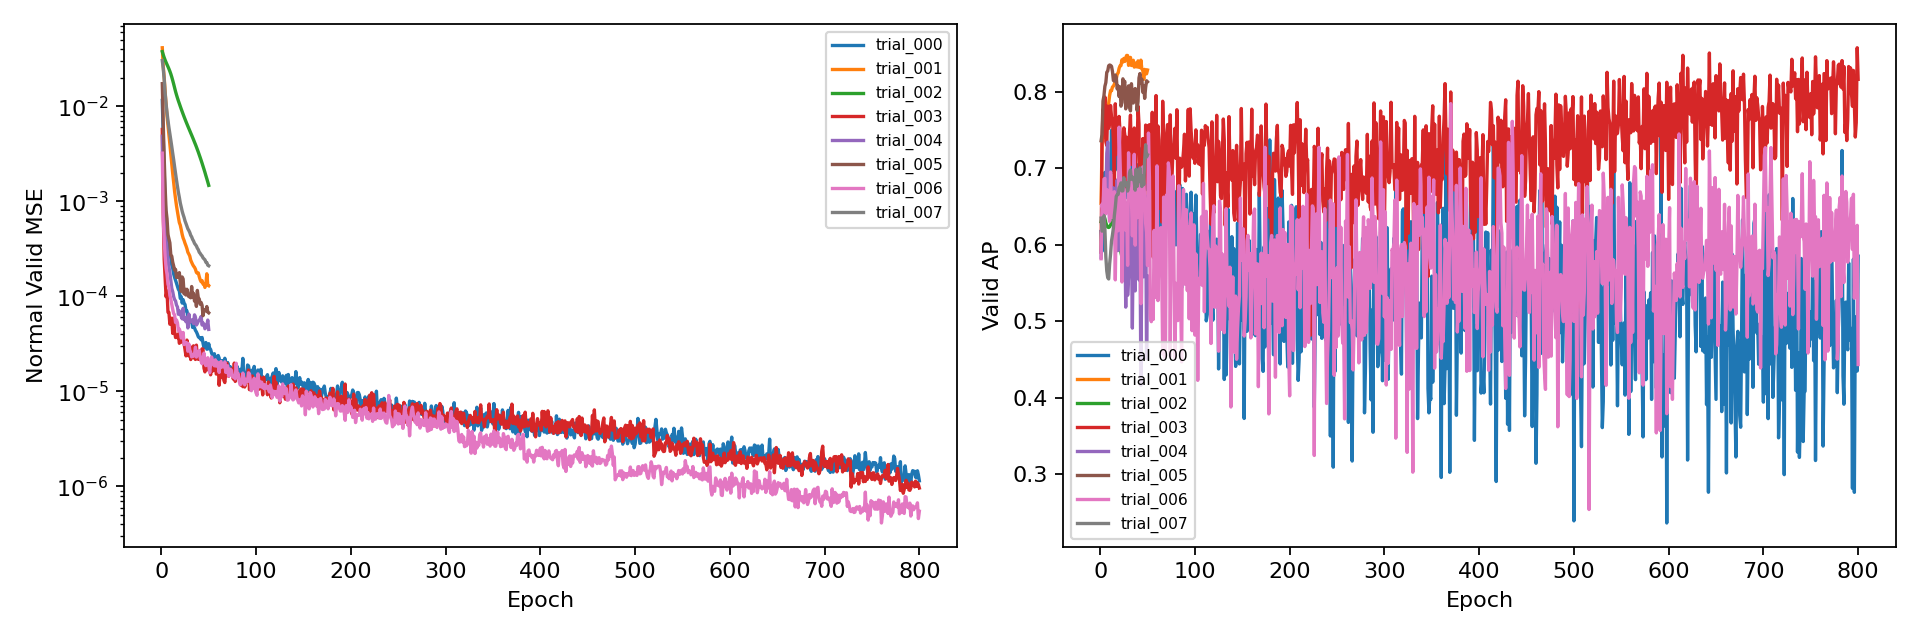

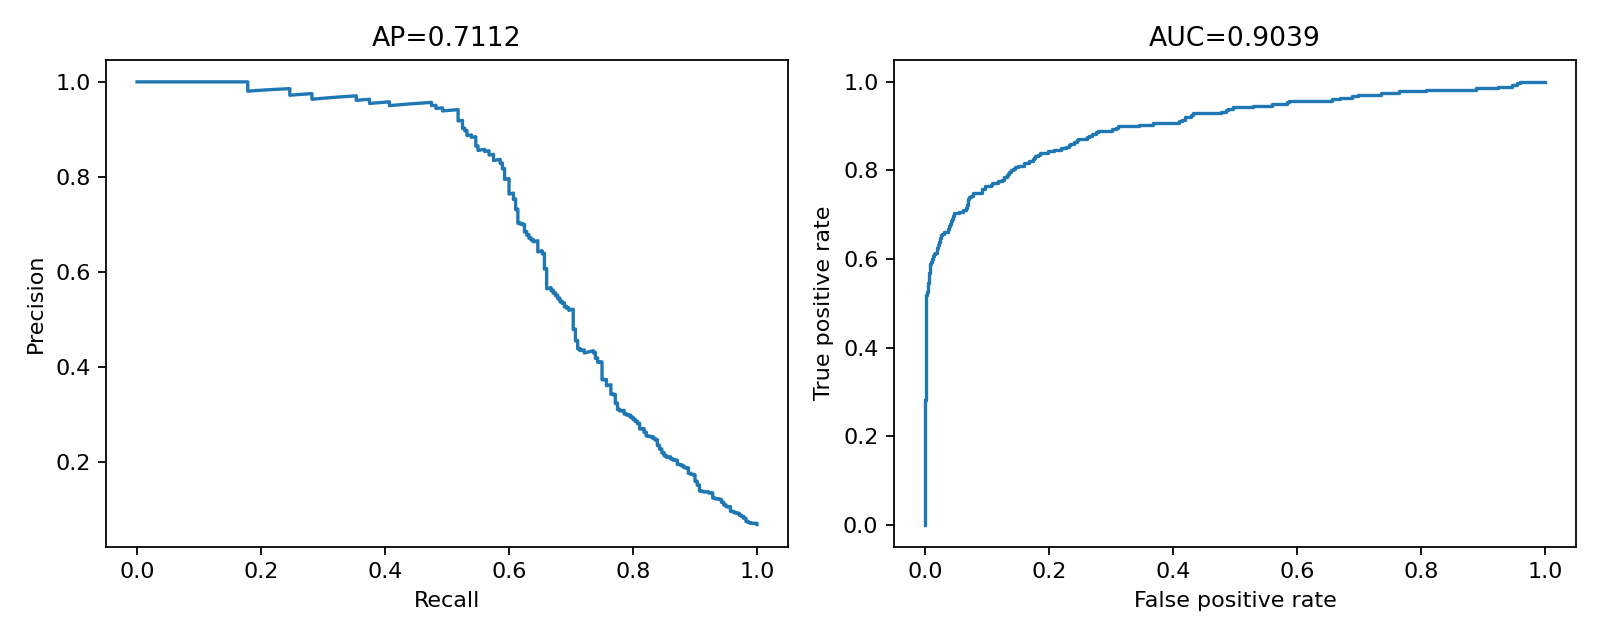

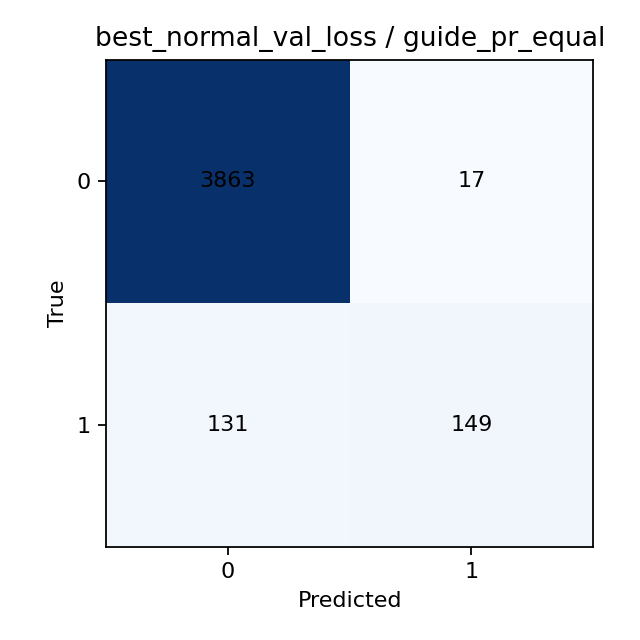

최종 비교표: /content/drive/MyDrive/KAMP_comparison_v4_validloss_all/moderntcn/moderntcn_validloss_all_20261002T140427Z_42fb396d/test/comparison.csv
최종 가중치: /content/drive/MyDrive/KAMP_comparison_v4_validloss_all/moderntcn/moderntcn_validloss_all_20261002T140427Z_42fb396d/final_candidate


In [28]:
from IPython.display import display, Image
for name in ['hpo_curves.png', 'best_normal_val_loss_curves.png', 'best_normal_val_loss_guide_pr_equal_confusion.png']:
    image_path = OUTPUT_DIR / 'test' / name
    if image_path.exists():
        display(Image(filename=str(image_path)))
print('최종 비교표:', OUTPUT_DIR/'test/comparison.csv')
print('최종 가중치:', OUTPUT_DIR/'final_candidate')


## 진행 결과 다시 보기 / 디버깅
이 셀은 학습을 시작하지 않습니다. 중단된 후보의 history를 확인하거나 선택한 trial의 로그를 읽습니다. 학습 중 오류 직후에는 새 셀에서 `%debug`를 실행할 수 있습니다.


,epoch,train/rec,train/total,grad_first_batch/rec,gradient_participating_parameters,nonzero_gradient_elements_first_batch,grad_first_batch/total,normal_valid_loss,valid_ap,valid_roc_auc,...,ap_wait,global_step,train_seconds,valid_seconds,compute_seconds,parameters_total,parameters_trainable,gpu_peak_bytes,stop_reason,trial_number
780,781,0.000011,0.000011,0.000600,378504,330120,0.000600,0.000001,0.591927,0.859195,...,189,85129,1.886306,0.093548,1.979854,378504,378504,112440320,NaN,0
781,782,0.000011,0.000011,0.000761,378504,330120,0.000761,0.000001,0.563582,0.853537,...,190,85238,1.877183,0.093590,1.970773,378504,378504,112440320,NaN,0
782,783,0.000011,0.000011,0.000633,378504,330120,0.000633,0.000001,0.723199,0.900339,...,191,85347,1.949796,0.094424,2.044220,378504,378504,112440320,NaN,0
783,784,0.000011,0.000011,0.000475,378504,330120,0.000475,0.000001,0.428217,0.851656,...,192,85456,1.948074,0.099373,2.047448,378504,378504,112440320,NaN,0
784,785,0.000011,0.000011,0.000665,378504,330120,0.000665,0.000002,0.391387,0.729508,...,193,85565,1.930583,0.095353,2.025936,378504,378504,112440320,NaN,0
785,786,0.000011,0.000011,0.000646,378504,330120,0.000646,0.000001,0.517447,0.812513,...,194,85674,1.886441,0.095459,1.981900,378504,378504,112440320,NaN,0
786,787,0.000011,0.000011,0.000651,378504,330120,0.000651,0.000001,0.524955,0.865951,...,195,85783,1.877971,0.094777,1.972749,378504,378504,112440320,NaN,0
787,788,0.000011,0.000011,0.000529,378504,330120,0.000529,0.000001,0.472454,0.812394,...,196,85892,1.862240,0.094530,1.956770,378504,378504,112440320,NaN,0
788,789,0.000011,0.000011,0.000561,378504,330120,0.000561,0.000001,0.462557,0.800445,...,197,86001,1.930895,0.096284,2.027178,378504,378504,112440320,NaN,0
789,790,0.000011,0.000011,0.000546,378504,330120,0.000546,0.000001,0.576284,0.869787,...,198,86110,1.917022,0.094545,2.011566,378504,378504,112440320,NaN,0


마지막 후보 설정: {}
디버깅 항목: []


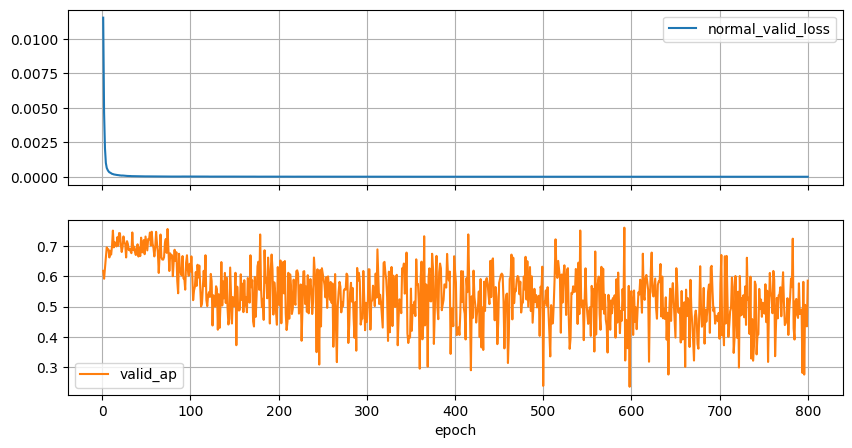

In [29]:
TRIAL_TO_VIEW = 0
history_path = OUTPUT_DIR / 'trials' / f'trial_{TRIAL_TO_VIEW:03d}' / 'history.csv'
local_history = LOCAL_DIR / 'trials' / f'trial_{TRIAL_TO_VIEW:03d}' / 'history.csv'
if local_history.exists():
    history_path = local_history
if history_path.exists():
    history_view = pd.read_csv(history_path)
    display(history_view.tail(20))
    history_view.plot(x='epoch', y=['normal_valid_loss', 'valid_ap'], subplots=True, figsize=(10, 5), grid=True)
else:
    print('아직 이 후보의 로그가 없습니다.')
if 'LAST_EXPERIMENT' in globals():
    print('마지막 후보 설정:', LAST_EXPERIMENT.debug_state.get('params', {}))
    print('디버깅 항목:', list(LAST_EXPERIMENT.debug_state))


## 결과 ZIP 만들기
VS Code에서는 Colab 파일 탐색기에서 ZIP을 다운로드하세요. 웹 Colab에서는 DOWNLOAD_IN_BROWSER=True로 받을 수 있습니다.


In [30]:
MAKE_RESULTS_ZIP = False
DOWNLOAD_IN_BROWSER = False
if MAKE_RESULTS_ZIP:
    result_zip = shutil.make_archive('/content/' + EXPERIMENT_ID + '_results', 'zip',
                                     root_dir=str(OUTPUT_DIR.parent), base_dir=OUTPUT_DIR.name)
    print('결과 ZIP:', result_zip)
    if DOWNLOAD_IN_BROWSER:
        from google.colab import files
        files.download(result_zip)


## 출처와 해석
중소벤처기업부, Korea AI Manufacturing Platform(KAMP), 소성가공 예지보전 AI 데이터셋, 스마트제조혁신추진단(㈜인터엑스), 2022.12.23., www.kamp-ai.kr

고정 offset 120은 120행 기준이며 실제 고장 전 경보 선행시간을 입증하지 않습니다. 가이드 원문과 v4의 분할·탐색 조건은 다릅니다.

### ModernTCN
https://github.com/luodhhh/ModernTCN

commit: `56a9a2c018385cd5acef015378cae7f084d1b11c`

```text
MIT License

Copyright (c) 2024 luodhhh

Permission is hereby granted, free of charge, to any person obtaining a copy
of this software and associated documentation files (the "Software"), to deal
in the Software without restriction, including without limitation the rights
to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
copies of the Software, and to permit persons to whom the Software is
furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all
copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE
AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM,
OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE
SOFTWARE.
```
